# *Created by Maedeh Torkian*

## EDA & Data Visualization:

#### EDA : preproccessing on Data(undrestanding data)

* Road:

1) Load the dataset

2) Check and undrestand the dataset -> df.sample| df.shape| df.describe| df.info| df.head/tail ...

3) Null handling

4) Remove duplicates

5) Skewness Correction

6) Outliers handling

7) Plots to visualize and undrestand data -> Data VIZ

8) 3D-Plots -> on Iris Dataset





#### 1- Load the Dataset : Adult dataset (UCI Repository)

In [8]:
# Install the ucimlrepo package
! pip install ucimlrepo



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\parsayan\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [ ]:
%pip install seaborn

In [ ]:
%pip install plotly

In [ ]:
%pip install bokeh

In [25]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
import seaborn as sns
import plotly.express as px  # --> a package to visualization
from bokeh.plotting import figure, show, output_notebook  # --> a package to visualization
from bokeh.models import HoverTool


In [ ]:
import sys
print(sys.executable)

In [10]:
!{sys.executable} -m pip install ucimlrepo


[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
from ucimlrepo import fetch_ucirepo
print("Import successful!")

Import successful!


In [ ]:
# Import the dataset into code
from ucimlrepo import fetch_ucirepo

# Fetch dataset
adult = fetch_ucirepo(name="adult")
type(adult)                    # --> ucimlrepo dotdict.dotdict

adult.keys()                   # --> dict_keys(['data', 'metadata', 'variables'])
# Data (as pandas dataframe)
X = adult.data.features
y = adult.data.targets

df = pd.concat([X,y], axis=1)  # join features column to target cloumn to et a dataframe
df                             # show the dataframe


In [68]:
# Or Using sklearn 
from sklearn.datasets import fetch_openml
adult = fetch_openml(name='adult', version=2, as_frame=True)

df = adult.frame


In [69]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


#### 2- Check and Undrestand Data

In [29]:
df.sample(5) # show 5 rows in random 


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
42328,41,State-gov,33126,Bachelors,13,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,40,United-States,>50K
35561,49,Self-emp-not-inc,107597,HS-grad,9,Divorced,Exec-managerial,Unmarried,White,Female,14084,0,30,United-States,>50K
6374,36,Private,416745,11th,7,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,<=50K
7430,46,Self-emp-inc,340651,Bachelors,13,Married-civ-spouse,Other-service,Husband,Black,Male,0,1977,60,United-States,>50K
42041,48,State-gov,120131,HS-grad,9,Divorced,Craft-repair,Own-child,White,Male,8614,0,40,United-States,>50K


In [30]:
df.shape  # Show size of the dataset

(48842, 15)

In [31]:
df.describe()  # Statistical description of the each columns

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [32]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [33]:
df.info()  # Describe type of each column's data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


In [34]:
df.nunique()  # show count of unique datas of each column

age                  74
workclass             8
fnlwgt            28523
education            16
education-num        16
marital-status        7
occupation           14
relationship          6
race                  5
sex                   2
capital-gain        123
capital-loss         99
hours-per-week       96
native-country       41
class                 2
dtype: int64

In [35]:
df.education.unique()

['11th', 'HS-grad', 'Assoc-acdm', 'Some-college', '10th', ..., 'Assoc-voc', '9th', '12th', '1st-4th', 'Preschool']
Length: 16
Categories (16, object): ['10th', '11th', '12th', '1st-4th', ..., 'Masters', 'Preschool', 'Prof-school', 'Some-college']

In [36]:
df.workclass.unique()

['Private', 'Local-gov', NaN, 'Self-emp-not-inc', 'Federal-gov', 'State-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked']
Categories (8, object): ['Federal-gov', 'Local-gov', 'Never-worked', 'Private', 'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Without-pay']

In [37]:
df['native-country'].unique()

['United-States', NaN, 'Peru', 'Guatemala', 'Mexico', ..., 'Greece', 'Trinadad&Tobago', 'Outlying-US(Guam-USVI-etc)', 'France', 'Holand-Netherlands']
Length: 42
Categories (41, object): ['Cambodia', 'Canada', 'China', 'Columbia', ..., 'Trinadad&Tobago', 'United-States', 'Vietnam', 'Yugoslavia']

#### 3- Null Handling:

Here is two method, by in this project use KNN.

In [ ]:
df.isnull().sum() # counts of null datas
df.isnull().sum().sum() # sum of all null datas == 2203


In [ ]:
# fill null values
df.fillna(method='ffill', inplace=True)
# To check do right:
df.isnull().sum().sum() # --> 0 => it does right!


In [38]:
numeric_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include='object').columns

In [ ]:
%pip install scikit-learn

In [39]:
# Redefine categorical and numeric columns fresh
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Found {len(numeric_cols)} numeric columns: {numeric_cols}")
print(f"Found {len(cat_cols)} categorical columns: {cat_cols}")

Found 6 numeric columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Found 9 categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'class']


In [40]:
# KNN Imputer for Numeric Data
from sklearn.impute import KNNImputer
# For categorical data, you should use strategy='most_frequent' or 'constant'
from sklearn.impute import SimpleImputer

knn_imputer = KNNImputer(n_neighbors=5)
df1_imputed = knn_imputer.fit_transform(df[numeric_cols])
df1 = pd.DataFrame(df1_imputed, columns=numeric_cols)

# For categorical columns - SimpleImputer with most_frequent strategy
simple_imputer = SimpleImputer(strategy='most_frequent')  # Changed from default 'mean'
df2_imputer = simple_imputer.fit_transform(df[cat_cols])
df2 = pd.DataFrame(df2_imputer, columns=cat_cols).isnull().sum()

# Combine numeric and categorical dataframes
df_new = pd.concat([df1, df2], axis=1)


# Check for any remaining null values
print("Remaining null values after imputation:")
print(df_new.isnull().sum())

Remaining null values after imputation:
age                   9
fnlwgt                9
education-num         9
capital-gain          9
capital-loss          9
hours-per-week        9
0                 48842
dtype: int64


#### Alternative Strategies for Categorical Data

* Option 1: Most frequent (mode) - Best for most cases
simple_imputer = SimpleImputer(strategy='most_frequent')

* Option 2: Constant value (e.g., 'Unknown')
simple_imputer = SimpleImputer(strategy='constant', fill_value='Unknown')

* Option 3: Using pandas directly (simpler)
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

#### If you want to use KNN for categorical data, you need to encode them first:

In [41]:
from sklearn.preprocessing import LabelEncoder

# Make a copy of 'df'
df_encoded = df.copy()

# Encode categorical columns to numeric
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    # Handle Null values temporarily
    df_encoded[col] = df_encoded[col].astype(str)
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

# Combine all columns for KNN imputation
all_cols = numeric_cols + cat_cols
knn_imputer = KNNImputer(n_neighbors=5)
df_imputed_encoded = knn_imputer.fit_transform(df_encoded[all_cols])

# Convert back to DataFrame
df_imputed = pd.DataFrame(df_imputed_encoded, columns=all_cols)

# Decode categorical columns back to original strings
for col in cat_cols:
    df_imputed[col] = df_imputed[col].round().astype(int)
    df_imputed[col] = label_encoders[col].inverse_transform(df_imputed[col])

print('Missing values after KNN imputation:')
print(df_imputed.isnull().sum())

Missing values after KNN imputation:
age               0
fnlwgt            0
education-num     0
capital-gain      0
capital-loss      0
hours-per-week    0
workclass         0
education         0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
native-country    0
class             0
dtype: int64


#### 4- Remove Duplicates:

In [42]:
df.duplicated().sum() # --> 29 rows
df.drop_duplicates(inplace=True)
# Checking:
df.duplicated().sum() # --> 0 


np.int64(0)

#### 5- Skewness Correction

In [43]:
# check skewness only on numeric columns
print("Skewness of numeric columns before imputation:")
print(df[numeric_cols].skew())

Skewness of numeric columns before imputation:
age                0.556582
fnlwgt             1.439698
education-num     -0.314229
capital-gain      11.888265
capital-loss       4.567037
hours-per-week     0.239652
dtype: float64


C:\Users\parsayan\AppData\Local\Temp\ipykernel_44932\3121902881.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for level, group in skew_df.groupby('Skewness_Level'):


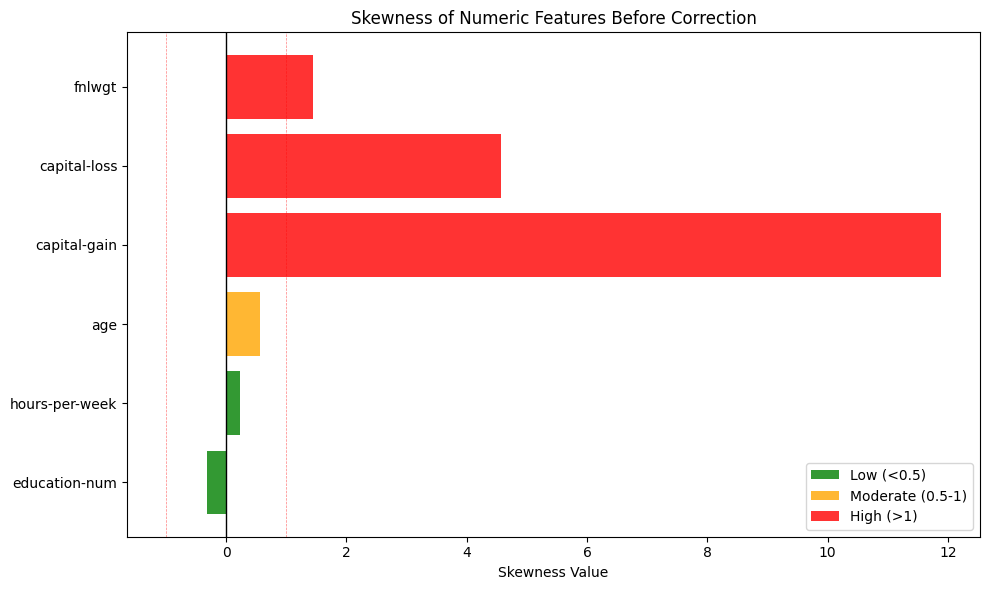


Skewness Summary:
       Feature  Skewness  Absolute_Skewness   Skewness_Level
  capital-gain 11.888265          11.888265        High (>1)
  capital-loss  4.567037           4.567037        High (>1)
        fnlwgt  1.439698           1.439698        High (>1)
           age  0.556582           0.556582 Moderate (0.5-1)
 education-num -0.314229           0.314229       Low (<0.5)
hours-per-week  0.239652           0.239652       Low (<0.5)


In [44]:
# Skewness information in a plot
skew_df = pd.DataFrame({
    'Feature': numeric_cols,
    'Skewness': [df[col].skew() for col in numeric_cols],
    'Absolute_Skewness': [abs(df[col].skew()) for col in numeric_cols]
}).sort_values('Absolute_Skewness', ascending=False)

# Categorize skewness levels
skew_df['Skewness_Level'] = pd.cut(skew_df['Absolute_Skewness'], 
                                    bins=[0, 0.5, 1, float('inf')],
                                    labels=['Low (<0.5)', 'Moderate (0.5-1)', 'High (>1)'])

# Create a styled table
fig, ax = plt.subplots(figsize=(10, 6))
colors = {'Low (<0.5)': 'green', 'Moderate (0.5-1)': 'orange', 'High (>1)': 'red'}
for level, group in skew_df.groupby('Skewness_Level'):
    ax.barh(group['Feature'], group['Skewness'], 
            color=colors[level], label=level, alpha=0.8)

ax.axvline(x=0, color='black', linewidth=1)
ax.axvline(x=1, color='red', linestyle='--', linewidth=0.5, alpha=0.5)
ax.axvline(x=-1, color='red', linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_xlabel('Skewness Value')
ax.set_title('Skewness of Numeric Features Before Correction')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Print the table
print("\nSkewness Summary:")
print(skew_df.to_string(index=False))

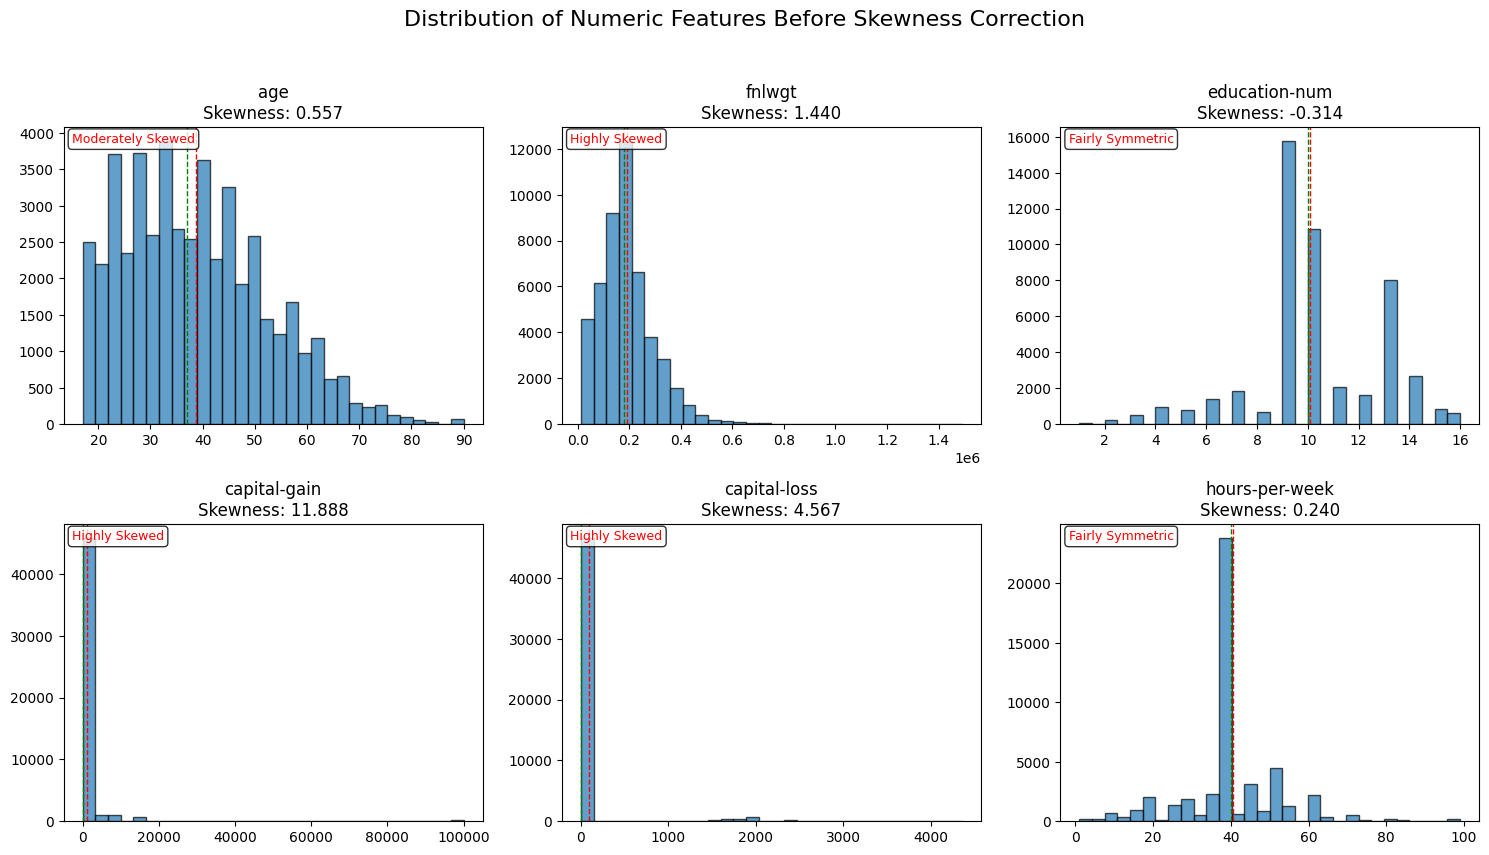

In [45]:
# Plot histograms for each numeric column with skewness value
fig, axes = plt.subplots(len(numeric_cols)//3 + 1, 3, figsize=(15, 4*((len(numeric_cols)//3)+1)))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    skew_val = df[col].skew()
    
    axes[i].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col}\nSkewness: {skew_val:.3f}')
    axes[i].axvline(df[col].mean(), color='red', linestyle='dashed', linewidth=1, label='Mean')
    axes[i].axvline(df[col].median(), color='green', linestyle='dashed', linewidth=1, label='Median')
    
    # Add interpretation
    if abs(skew_val) < 0.5:
        interp = 'Fairly Symmetric'
    elif 0.5 <= abs(skew_val) < 1:
        interp = 'Moderately Skewed'
    else:
        interp = 'Highly Skewed'
    
    axes[i].text(0.02, 0.98, interp, transform=axes[i].transAxes, 
                verticalalignment='top', fontsize=9, color='red',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Remove empty subplots
for j in range(i+1, len(axes)):
    axes[j].remove()

plt.suptitle('Distribution of Numeric Features Before Skewness Correction', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [46]:
from scipy import stats
from scipy.stats import yeojohnson


def skewness_handler(df, threshold=1.0, verbose=True):
    """
    Handles skewness with proper variable initialization and robust fallbacks
    """
    normal_df = df.copy()
    normal_dict = {}

    for col in normal_df.select_dtypes(include=[np.number]).columns:
        data = normal_df[col].dropna()
        skewness = data.skew()

        if abs(skewness) > threshold:
            if verbose:
                print(f'\nProcessing {col} (skewness: {skewness:.3f})')

            # Check for constant or near-constant columns
            if data.nunique() <= 1:
                if verbose:
                    print('Skipping constant column')
                continue
            # Initialize data_clipped to data by default
            data_clipped = data.copy()

            # Sterategy1: Handle zero-inflated data
            zero_ratio = (data == 0).sum() / len(data)
            if zero_ratio > 0.1:
                non_zero = data[data != 0]
                if len(non_zero) > 10: # Enough non-zero values
                    if verbose:
                        print(f' -> Zero-inflated ({zero_ratio:.1%} zero)')

                    # Try Yeo-Johnson on non-zero values
                    try:
                        transformed, lambda_param = yeojohnson(non_zero)
                        normal_df.loc[data != 0, col] = transformed
                        normal_dict[col] = {
                            'method': 'yeo-johnson (non-zero)',
                            'lambda': lambda_param,
                            'zero_ratio': zero_ratio,
                        }
                        if verbose:
                            print(f'Yeo-Johnson applied (λ = {lambda_param:.3f})')
                        continue
                    except:
                        pass

                    # Fallback to log1p
                    normal_df.loc[data != 0, col] = np.log1p(non_zero)
                    normal_dict[col] = {
                        'method': 'log1p (non-zero)',
                        'lambda': None,
                        'zero-ratio': zero_ratio,
                    }
                    if verbose:
                        print('Log1p applied to non-zero values')
                    continue
            
            # Sterategy2: Winsorize extreme outliers first 
            if abs(skewness) > 5:
                q1, q3 = data.quantile([0.01, 0.99])
                data_clipped = data.clip(q1, q3)
                if verbose:
                    print('-> Extreme skewness, winsorizing at 1st/99th percentile')
                else:
                    data_clipped = data
            
            # Sterategy3: Yeo-Johnson (handles negative values)
            try:
                transformed, lambda_param = yeojohnson(data_clipped)
                normal_df.loc[data.index, col] = transformed
                normal_dict[col] = {
                    'method': 'yeo-johnson',
                    'lambda': lambda_param,
                    'shift': 0,
                }
                if verbose:
                    print(f'Yeo-Johnson applied (λ= {lambda_param:.3f})')
            except:
                # Sterategy4: Box-Cox with automatic shift
                min_val = data.min()
                if min_val <= 0:
                    shift = abs(min_val) + 1
                    shifted_data = data_clipped + shift
                else:
                    shift = 0
                    shifted_data = data_clipped

            try:
                normal_data, lambda_param = stats.boxcox(shifted_data)
                normal_df.loc[data.index, col] = transformed
                normal_dict[col] = {
                    'method': 'box-cox',
                    'lambda': lambda_param,
                    'shift': shift,
                }
                if verbose:
                    print(f'Box-Cox applied (λ = {lambda_param:.3f}, shift= {shift})')
            except:
                # Sterategy 5: Simple transformations as fallback
                if skewness > 0: # Right-skewed
                    if (data_clipped.max() / max(data_clipped.min(), 1e-10)) > 100:
                        normal_df.loc[data.index, col] = np.log1p(data_clipped)
                        method = 'log1p'
                    else:
                        normal_df.loc[data.index, col] = np.sqrt(data_clipped)
                        method = 'sqrt'
                else: #Left-skewed
                    # Reflect and transform
                    max_val = data_clipped.max()
                    reflected = max_val + 1 - data_clipped
                    normal_df.loc[data.index, col] = np.log1p(reflected)
                    method = 'log1p (reflected)'

                normal_dict[col] = {
                    'method': method,
                    'lambda': None,
                    'shift': 0,
                }          
                if verbose:
                    print(f'{method} applied (fallback)')
        else:
            if verbose:
                print(f'{col} alredy normal (skewness: {skewness:.3f})')
            normal_dict[col] = {
                'method': 'none', 
                'lambda': None,
                'shift': 0,
            }
    return normal_df, normal_dict         
            

# Apply the handler
normaled_df, normals = skewness_handler(df, threshold=1.0)

age alredy normal (skewness: 0.557)

Processing fnlwgt (skewness: 1.440)
Yeo-Johnson applied (λ= 0.417)
log1p applied (fallback)
education-num alredy normal (skewness: -0.314)

Processing capital-gain (skewness: 11.888)
 -> Zero-inflated (91.7% zero)
Yeo-Johnson applied (λ = -0.125)

Processing capital-loss (skewness: 4.567)
 -> Zero-inflated (95.3% zero)
Yeo-Johnson applied (λ = 1.074)
hours-per-week alredy normal (skewness: 0.240)


C:\Users\parsayan\AppData\Local\Temp\ipykernel_44932\1928559778.py:74: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[408.19715412 276.61993162 481.90128828 ... 344.99509168 388.42488348
 451.16278375]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  normal_df.loc[data.index, col] = transformed
C:\Users\parsayan\AppData\Local\Temp\ipykernel_44932\1928559778.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[5.38237152 5.06893238 5.32279547 ... 5.59197059 4.6590693  5.59205048]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  normal_df.loc[data != 0, col] = transformed
C:\Users\parsayan\AppData\Local\Temp\ipykernel_44932\1928559778.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future 

* Plot the skewness before and after normalized

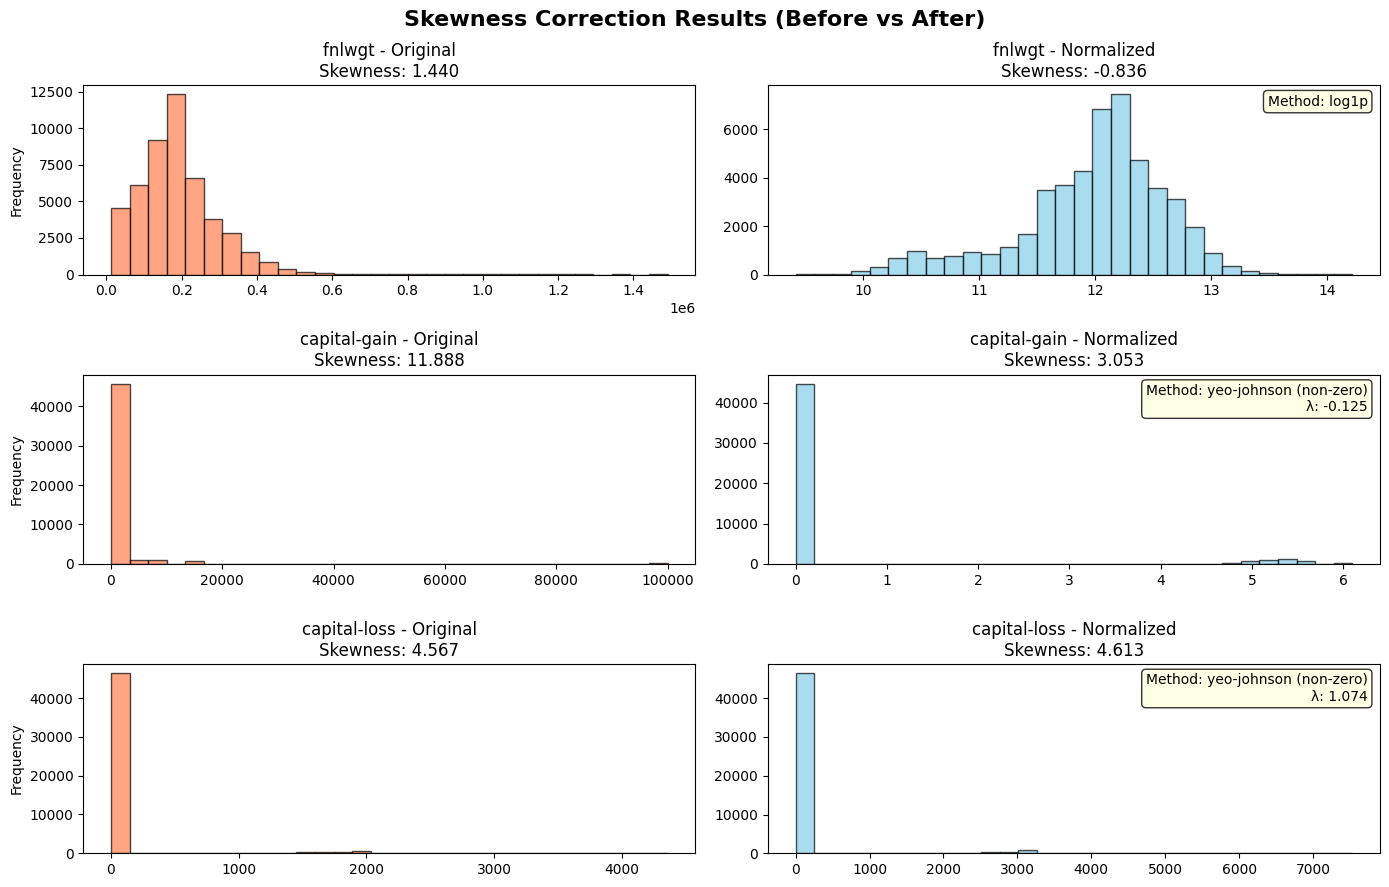

In [47]:
import matplotlib.pyplot as plt
import numpy as np

def plot_skewness_static(df_original, df_normalized, normal_dict, numeric_cols=None):
    """
    Static Matplotlib visualization - no nbformat needed
    """
    if numeric_cols is None:
        numeric_cols = df_original.select_dtypes(include=[np.number]).columns
    
    transformed_cols = [col for col in numeric_cols 
                       if normal_dict.get(col, {}).get('method', 'none') != 'none']
    
    if not transformed_cols:
        print("No columns were transformed!")
        return
    
    n_cols = len(transformed_cols)
    fig, axes = plt.subplots(n_cols, 2, figsize=(14, 3*n_cols))
    
    # Handle case with only one transformed column
    if n_cols == 1:
        axes = axes.reshape(1, -1)
    
    for i, col in enumerate(transformed_cols):
        # Original distribution
        axes[i, 0].hist(df_original[col].dropna(), bins=30, color='coral', 
                       alpha=0.7, edgecolor='black')
        axes[i, 0].set_title(f'{col} - Original\nSkewness: {df_original[col].skew():.3f}')
        axes[i, 0].set_ylabel('Frequency')
        
        # Normalized distribution
        axes[i, 1].hist(df_normalized[col].dropna(), bins=30, color='skyblue', 
                       alpha=0.7, edgecolor='black')
        axes[i, 1].set_title(f'{col} - Normalized\nSkewness: {df_normalized[col].skew():.3f}')
        
        # Add method info
        method = normal_dict[col].get('method', 'unknown')
        lambda_val = normal_dict[col].get('lambda', None)
        info = f"Method: {method}"
        if lambda_val:
            info += f"\nλ: {lambda_val:.3f}"
        axes[i, 1].text(0.98, 0.95, info, transform=axes[i, 1].transAxes,
                       verticalalignment='top', horizontalalignment='right',
                       bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    plt.suptitle('Skewness Correction Results (Before vs After)', 
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Use the static version
plot_skewness_static(df, normaled_df, normals)

#### 6- Outlier Handling:


age: 215 outliers (0.4%)
fnlwgt: 1453 outliers (3.0%)
education-num: 1787 outliers (3.7%)
capital-gain: 4035 outliers (8.3%)
capital-loss: 2282 outliers (4.7%)
hours-per-week: 13486 outliers (27.6%)


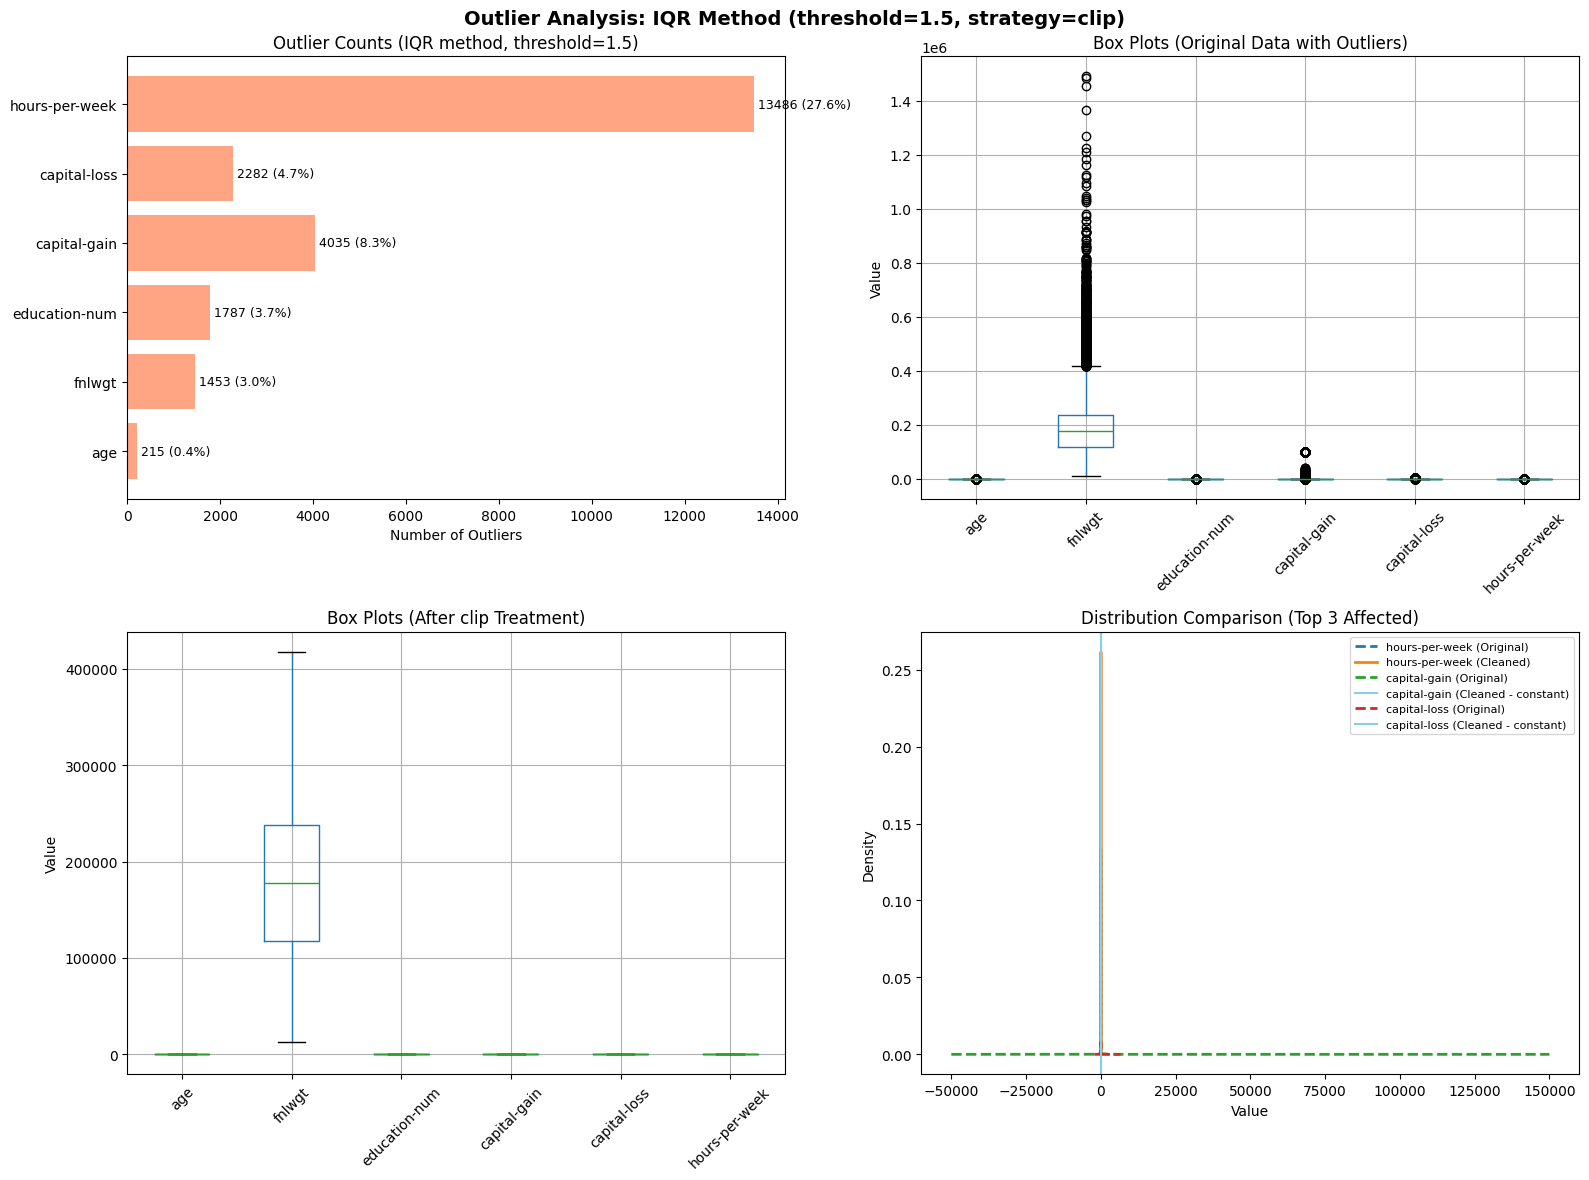

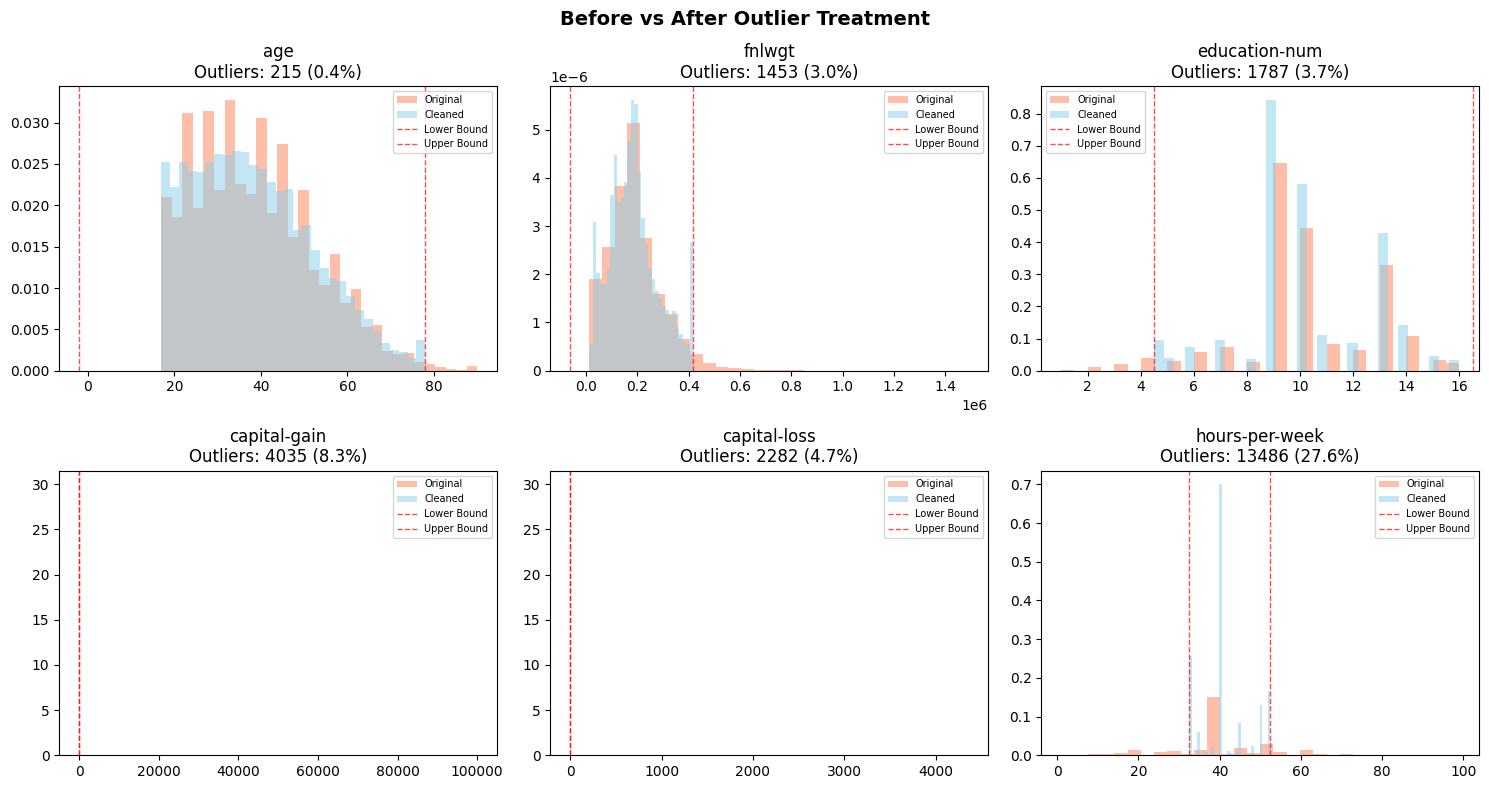


OUTLIER DETECTION SUMMARY
        Column  Outliers_Count Outliers_Pct Lower_Bound Upper_Bound
           age             215        0.44%       -2.00       78.00
        fnlwgt            1453        2.98%   -62521.88   417683.12
 education-num            1787        3.66%        4.50       16.50
  capital-gain            4035        8.27%         N/A         N/A
  capital-loss            2282        4.68%         N/A         N/A
hours-per-week           13486       27.64%       32.50       52.50
age: 185 outliers (0.4%)
fnlwgt: 506 outliers (1.0%)
education-num: 326 outliers (0.7%)
capital-gain: 331 outliers (0.7%)
capital-loss: 2216 outliers (4.5%)
hours-per-week: 681 outliers (1.4%)


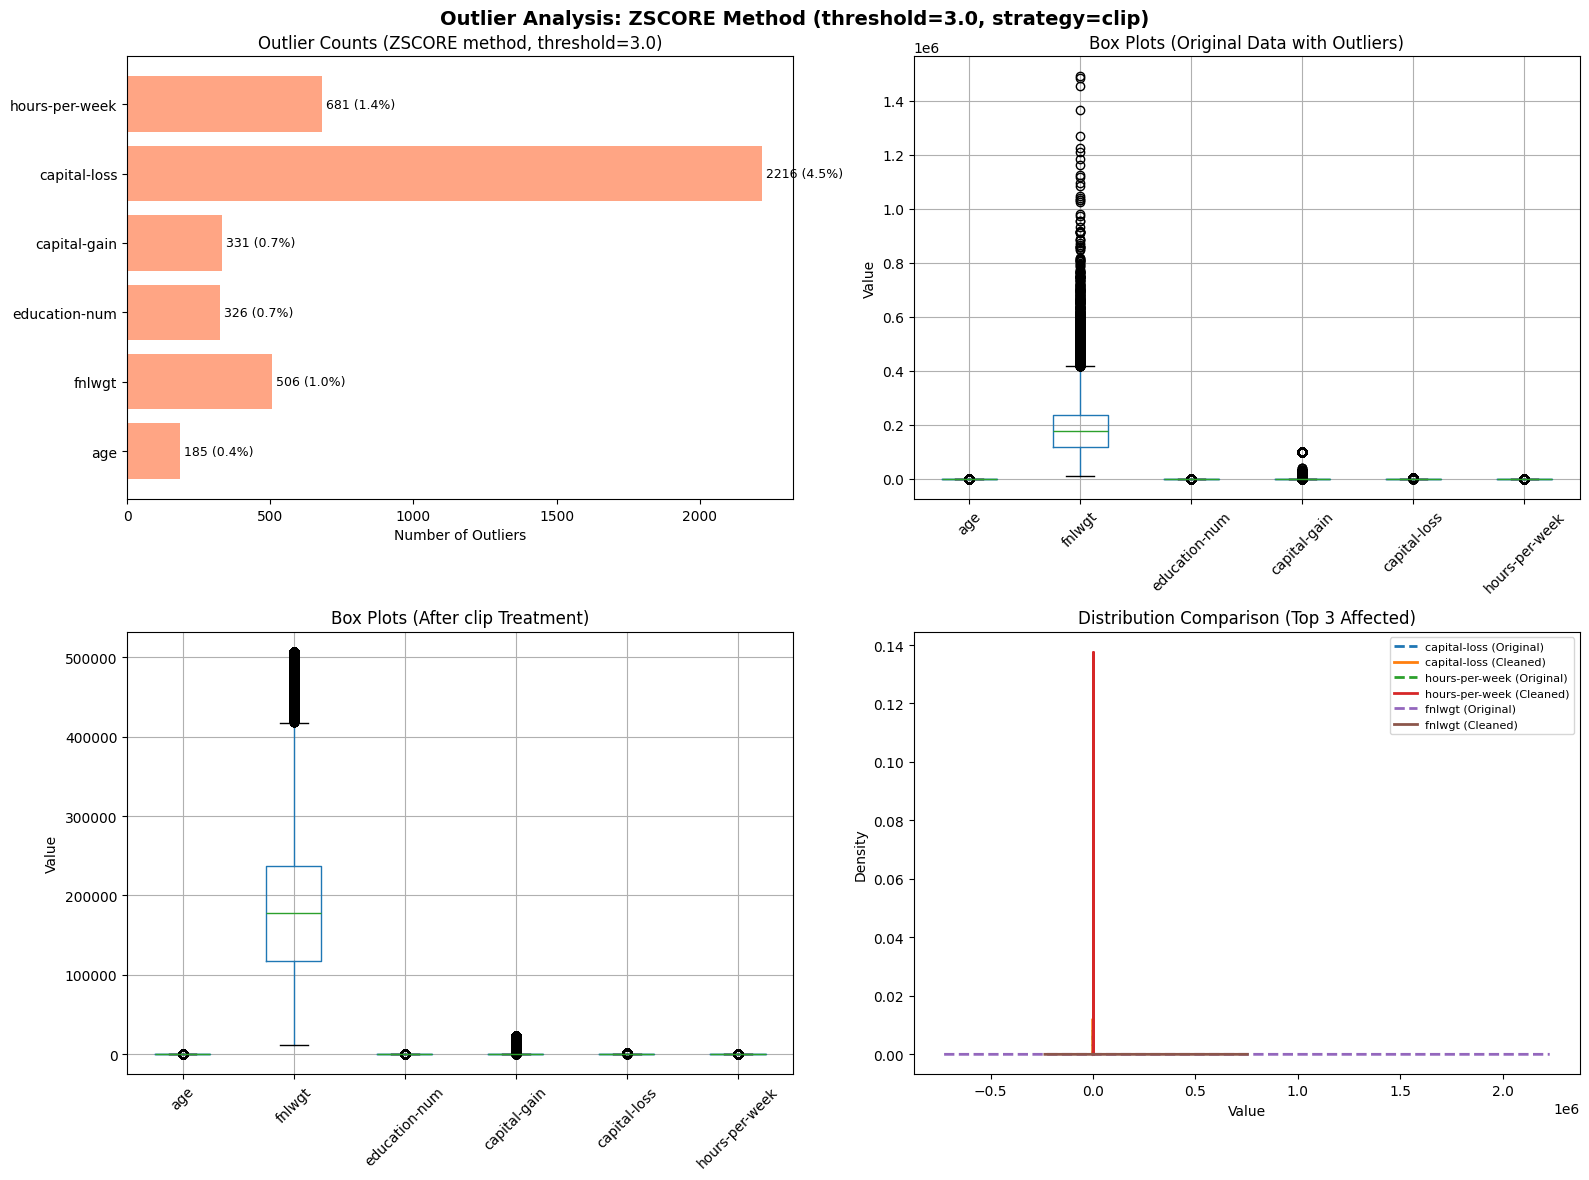

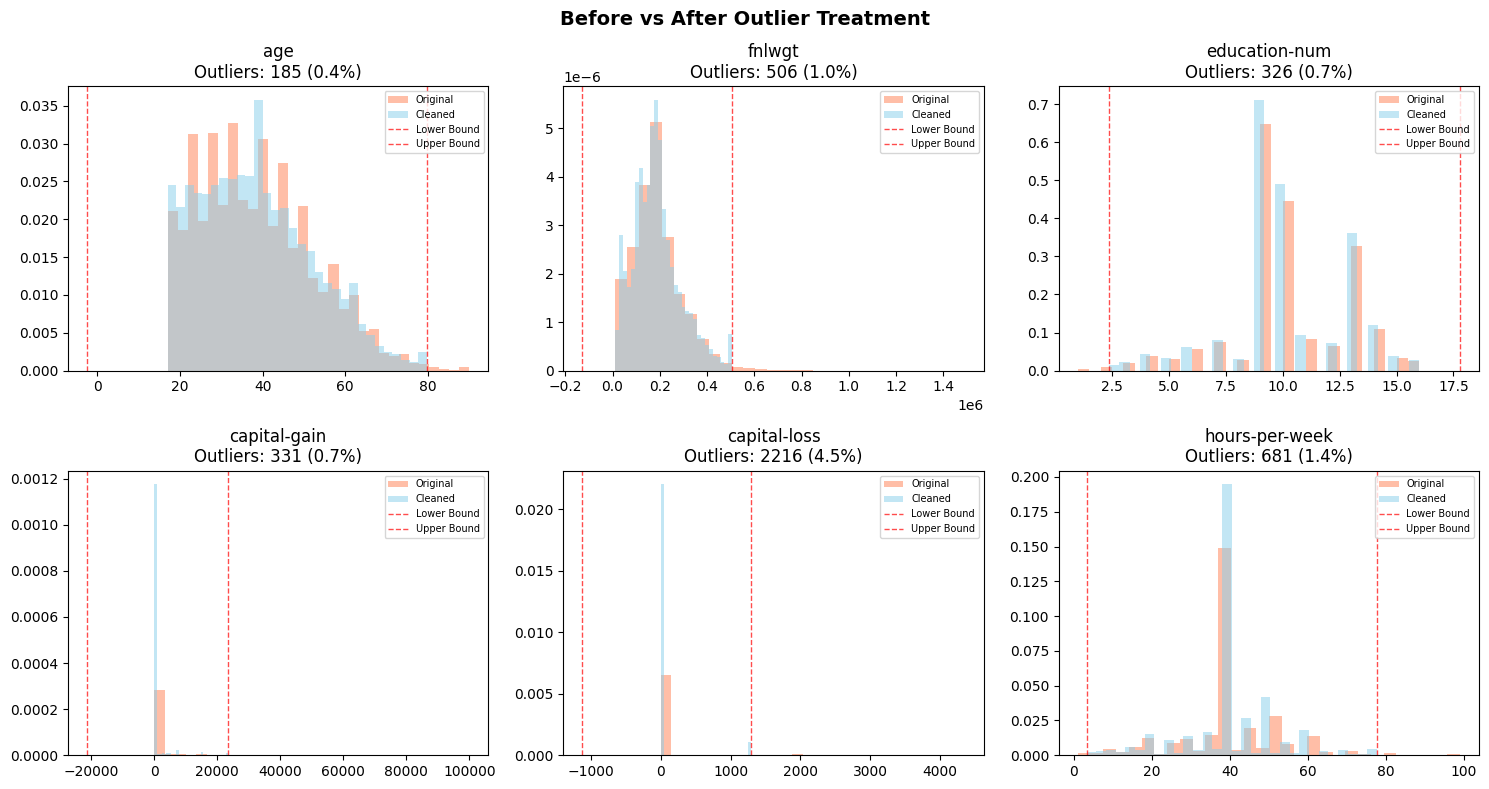


OUTLIER DETECTION SUMMARY
        Column  Outliers_Count Outliers_Pct Lower_Bound Upper_Bound
           age             185        0.38%       -2.47       79.78
        fnlwgt             506        1.04%  -127182.69   506520.69
 education-num             326        0.67%        2.37       17.79
  capital-gain             331        0.68%   -21287.50    23447.94
  capital-loss            2216        4.54%    -1122.03     1297.22
hours-per-week             681        1.40%        3.25       77.60
age: 215 outliers (0.4%)
fnlwgt: 1453 outliers (3.0%)
education-num: 1787 outliers (3.7%)
capital-gain: 4035 outliers (8.3%)
capital-loss: 2282 outliers (4.7%)
hours-per-week: 13486 outliers (27.6%)


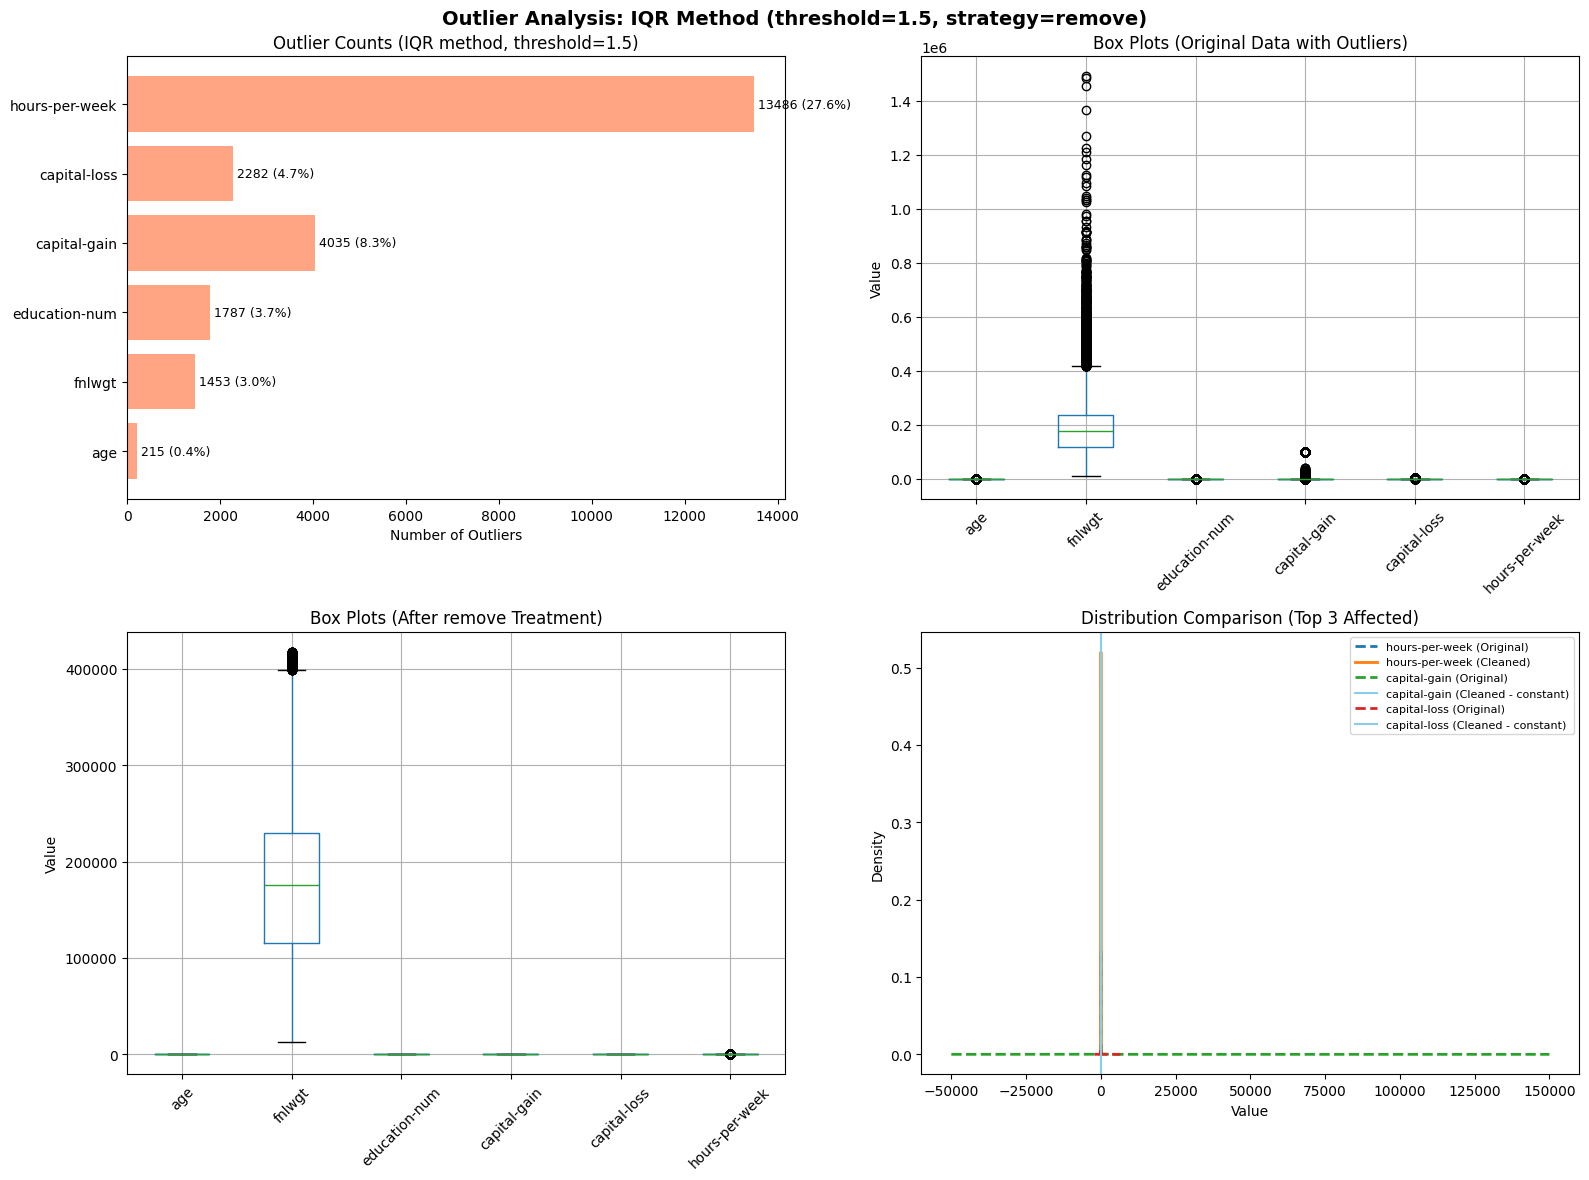

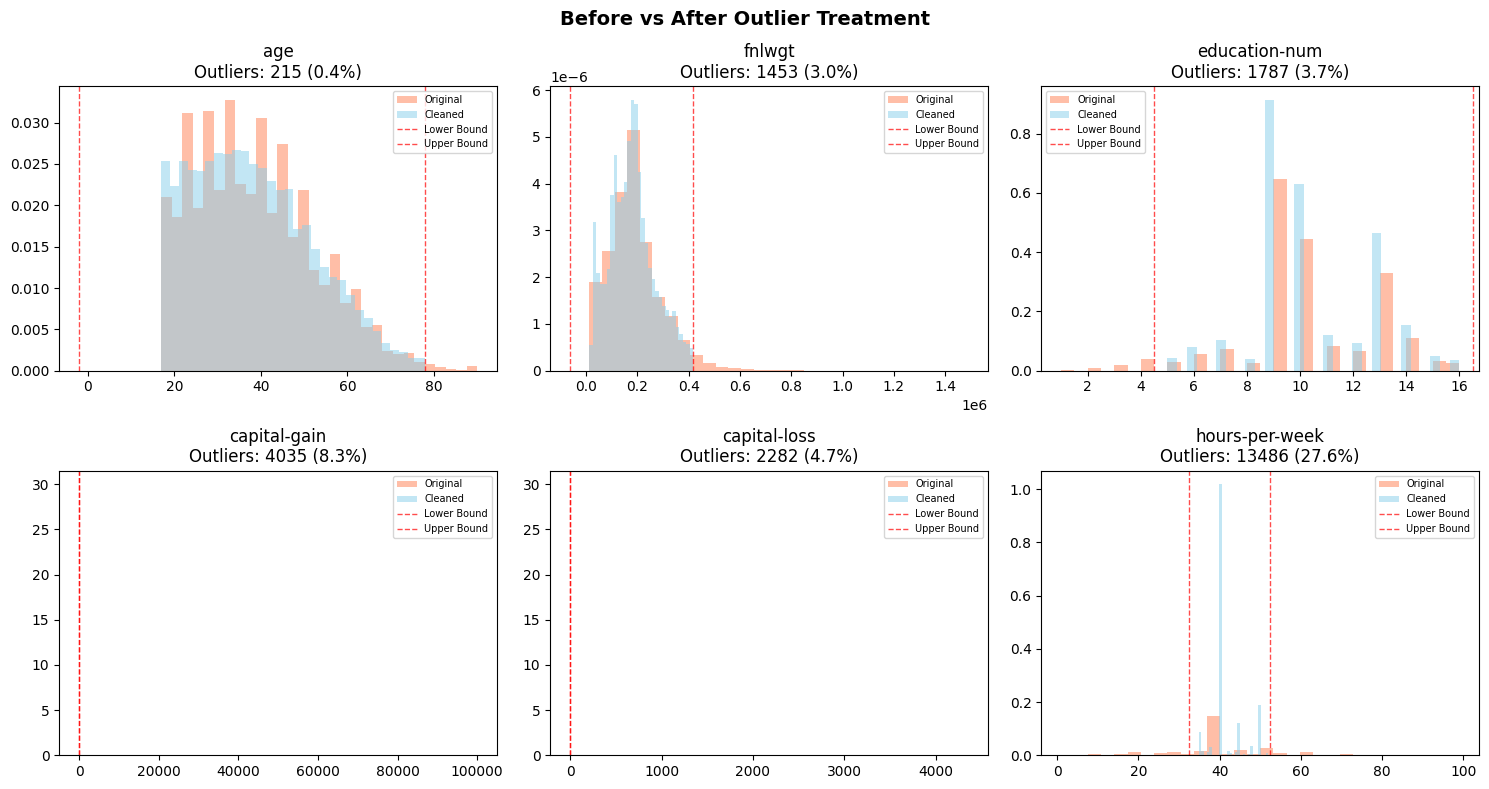


OUTLIER DETECTION SUMMARY
        Column  Outliers_Count Outliers_Pct Lower_Bound Upper_Bound
           age             215        0.44%       -2.00       78.00
        fnlwgt            1453        2.98%   -62521.88   417683.12
 education-num            1787        3.66%        4.50       16.50
  capital-gain            4035        8.27%         N/A         N/A
  capital-loss            2282        4.68%         N/A         N/A
hours-per-week           13486       27.64%       32.50       52.50

Outlier comparison across methods:

age:
  IQR: 215 outliers
  Z-score: 185 outliers

fnlwgt:
  IQR: 1453 outliers
  Z-score: 506 outliers

education-num:
  IQR: 1787 outliers
  Z-score: 326 outliers

capital-gain:
  IQR: 4035 outliers
  Z-score: 331 outliers

capital-loss:
  IQR: 2282 outliers
  Z-score: 2216 outliers


In [48]:
# Outlier Detection, Handling & Visualization Function
def outlier_handler(df, method='iqr', threshold=1.5, strategy='clip', plot=True, verbose=True):
    """
    Comprehensive outlier detection, handling, and visualization
    
    Parameters:
    -----------
    df : DataFrame
        Input dataframe
    method : str
        Detection method: 'iqr' (Interquartile Range), 'zscore', 'isolation_forest', 'lof'
    threshold : float
        Threshold for outlier detection:
        - IQR: multiplier (default 1.5 for mild, 3.0 for extreme)
        - Z-score: standard deviations (default 3.0)
    strategy : str
        Handling strategy: 'clip' (winsorize), 'remove', 'nan', 'mean', 'median'
    plot : bool
        Whether to generate plots
    verbose : bool
        Whether to print information
    
    Returns:
    --------
    df_clean : DataFrame with handled outliers
    outlier_info : Dictionary with outlier information
    """
    
    df_clean = df.copy()
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
    outlier_info = {}
    
    for col in numeric_cols:
        data = df_clean[col].dropna()
        
        if len(data) < 10:  # Skip columns with too few values
            continue
            
        # ---- DETECTION ----
        if method == 'iqr':
            Q1 = data.quantile(0.25)
            Q3 = data.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - threshold * IQR
            upper_bound = Q3 + threshold * IQR
            outliers = (data < lower_bound) | (data > upper_bound)
            
        elif method == 'zscore':
            z_scores = np.abs(stats.zscore(data))
            outliers = z_scores > threshold
            lower_bound = data.mean() - threshold * data.std()
            upper_bound = data.mean() + threshold * data.std()
            
        elif method == 'isolation_forest':
            from sklearn.ensemble import IsolationForest
            iso_forest = IsolationForest(contamination=0.1, random_state=42)
            outliers = iso_forest.fit_predict(data.values.reshape(-1, 1)) == -1
            lower_bound, upper_bound = None, None
            
        elif method == 'lof':
            from sklearn.neighbors import LocalOutlierFactor
            lof = LocalOutlierFactor(contamination=0.1)
            outliers = lof.fit_predict(data.values.reshape(-1, 1)) == -1
            lower_bound, upper_bound = None, None
        
        n_outliers = outliers.sum()
        pct_outliers = 100 * n_outliers / len(data)
        
        if n_outliers > 0:
            outlier_info[col] = {
                'count': n_outliers,
                'percentage': pct_outliers,
                'lower_bound': lower_bound,
                'upper_bound': upper_bound,
                'outlier_indices': data[outliers].index.tolist()
            }
            
            if verbose:
                print(f"{col}: {n_outliers} outliers ({pct_outliers:.1f}%)")
            
            # ---- HANDLING ----
            if strategy == 'clip':
                if lower_bound is not None and upper_bound is not None:
                    df_clean[col] = df_clean[col].clip(lower_bound, upper_bound)
                else:
                    # Fallback for methods without bounds
                    q1, q3 = data.quantile([0.25, 0.75])
                    iqr = q3 - q1
                    df_clean[col] = df_clean[col].clip(q1 - 1.5*iqr, q3 + 1.5*iqr)
                    
            elif strategy == 'remove':
                df_clean.loc[outliers[outliers].index, col] = np.nan
                
            elif strategy == 'nan':
                df_clean.loc[outliers[outliers].index, col] = np.nan
                
            elif strategy == 'mean':
                mean_val = data[~outliers].mean()
                df_clean.loc[outliers[outliers].index, col] = mean_val
                
            elif strategy == 'median':
                median_val = data[~outliers].median()
                df_clean.loc[outliers[outliers].index, col] = median_val
        else:
            if verbose:
                print(f"{col}: No outliers detected")
    
    # ---- VISUALIZATION ----
    if plot and outlier_info:
        plot_outlier_results(df, df_clean, outlier_info, method, threshold, strategy)
    
    return df_clean, outlier_info


def plot_outlier_results(df_original, df_cleaned, outlier_info, method, threshold, strategy):
    """
    Visualize outlier detection and handling results
    """
    outlier_cols = list(outlier_info.keys())
    
    if not outlier_cols:
        print("No outliers to plot!")
        return
    
    
    # 1. Summary Statistics Plot
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1.1 Bar chart of outlier counts
    ax1 = axes[0, 0]
    counts = [outlier_info[col]['count'] for col in outlier_cols]
    percentages = [outlier_info[col]['percentage'] for col in outlier_cols]
    
    bars = ax1.barh(outlier_cols, counts, color='coral', alpha=0.7)
    ax1.set_xlabel('Number of Outliers')
    ax1.set_title(f'Outlier Counts ({method.upper()} method, threshold={threshold})')
    
    # Add count labels
    for bar, pct in zip(bars, percentages):
        ax1.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                f' {int(bar.get_width())} ({pct:.1f}%)',
                va='center', fontsize=9)
    
    # 1.2 Box plots before cleaning
    ax2 = axes[0, 1]
    if len(outlier_cols) <= 10:  # Limit to 10 columns for readability
        df_original[outlier_cols].boxplot(ax=ax2, rot=45)
        ax2.set_title('Box Plots (Original Data with Outliers)')
        ax2.set_ylabel('Value')
    else:
        ax2.text(0.5, 0.5, f'Too many columns ({len(outlier_cols)}) to display boxplots',
                ha='center', va='center', transform=ax2.transAxes)
    
    # 1.3 Box plots after cleaning
    ax3 = axes[1, 0]
    if len(outlier_cols) <= 10:
        df_cleaned[outlier_cols].boxplot(ax=ax3, rot=45)
        ax3.set_title(f'Box Plots (After {strategy} Treatment)')
        ax3.set_ylabel('Value')
    else:
        ax3.text(0.5, 0.5, f'Too many columns ({len(outlier_cols)}) to display boxplots',
                ha='center', va='center', transform=ax3.transAxes)
    
    # 1.4 Distribution comparison for top 3 most affected columns
    ax4 = axes[1, 1]
    top_cols = sorted(outlier_cols, key=lambda x: outlier_info[x]['percentage'], reverse=True)[:3]
    
    for col in top_cols:
        # FIX: Check if data has variance before attempting KDE
        original_data = df_original[col].dropna()
        cleaned_data = df_cleaned[col].dropna()


        # Original distribution
        if original_data.nunique() > 1:  # Check if more than 1 unique value
            try:
                original_data.plot(kind='kde', ax=ax4, linestyle='--', 
                                  label=f'{col} (Original)', linewidth=2)
            except (np.linalg.LinAlgError, Exception):
                # Fallback to histogram if KDE fails
                original_data.hist(bins=30, ax=ax4, alpha=0.3, density=True,
                                  label=f'{col} (Original)', color='coral')
                
        else:
            ax4.axvline(original_data.iloc[0], color='coral', linestyle='--', 
                       label=f'{col} (Original - constant)')
            
                 # Cleaned distribution
        if cleaned_data.nunique() > 1:
            try:
                cleaned_data.plot(kind='kde', ax=ax4, linestyle='-', 
                                 label=f'{col} (Cleaned)', linewidth=2)
            except (np.linalg.LinAlgError, Exception):
                cleaned_data.hist(bins=30, ax=ax4, alpha=0.3, density=True,
                                 label=f'{col} (Cleaned)', color='skyblue')

        else:
            ax4.axvline(cleaned_data.iloc[0], color='skyblue', linestyle='-', 
                       label=f'{col} (Cleaned - constant)')      
    
    ax4.set_title(f'Distribution Comparison (Top {len(top_cols)} Affected)')
    ax4.set_xlabel('Value')
    ax4.set_ylabel('Density')
    ax4.legend(fontsize=8)
    
    plt.suptitle(f'Outlier Analysis: {method.upper()} Method (threshold={threshold}, strategy={strategy})',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 2. Detailed Before/After Histograms
    if len(outlier_cols) <= 10:
        n_rows = (len(outlier_cols) + 2) // 3
        fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4*n_rows))

        if n_rows == 1:
            axes = axes.reshape(1, -1)
        axes_flat = axes.flatten()
        
        for i, col in enumerate(outlier_cols):
            if i < len(axes_flat):
                ax = axes_flat[i]
                
                # Overlay histograms
                ax.hist(df_original[col].dropna(), bins=30, alpha=0.5, 
                       color='coral', label='Original', density=True)
                ax.hist(df_cleaned[col].dropna(), bins=30, alpha=0.5, 
                       color='skyblue', label='Cleaned', density=True)
                
                # Add bounds if available
                info = outlier_info[col]
                if info['lower_bound'] is not None:
                    ax.axvline(info['lower_bound'], color='red', linestyle='--', 
                              linewidth=1, alpha=0.7, label='Lower Bound')
                if info['upper_bound'] is not None:
                    ax.axvline(info['upper_bound'], color='red', linestyle='--', 
                              linewidth=1, alpha=0.7, label='Upper Bound')
                
                ax.set_title(f'{col}\nOutliers: {info["count"]} ({info["percentage"]:.1f}%)')
                ax.legend(fontsize=7)
        
        # Remove empty subplots
        for j in range(i+1, len(axes)):
            axes[j].remove()
        
        plt.suptitle('Before vs After Outlier Treatment', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    # 3. Summary table
    summary_df = pd.DataFrame({
        'Column': outlier_cols,
        'Outliers_Count': [outlier_info[col]['count'] for col in outlier_cols],
        'Outliers_Pct': [f"{outlier_info[col]['percentage']:.2f}%" for col in outlier_cols],
        'Lower_Bound': [f"{outlier_info[col]['lower_bound']:.2f}" if outlier_info[col]['lower_bound'] else 'N/A' 
                       for col in outlier_cols],
        'Upper_Bound': [f"{outlier_info[col]['upper_bound']:.2f}" if outlier_info[col]['upper_bound'] else 'N/A' 
                       for col in outlier_cols]
    })
    
    print("\n" + "="*80)
    print("OUTLIER DETECTION SUMMARY")
    print("="*80)
    print(summary_df.to_string(index=False))
    
    return summary_df


# Usage Examples
# ==============

# Example 1: IQR method with clipping
df_clean_iqr, info_iqr = outlier_handler(
    df, 
    method='iqr', 
    threshold=1.5, 
    strategy='clip',
    plot=True,
    verbose=True
)

# Example 2: Z-score method with winsorization
df_clean_zscore, info_zscore = outlier_handler(
    df, 
    method='zscore', 
    threshold=3.0, 
    strategy='clip',
    plot=True,
    verbose=True
)

# Example 3: Remove outliers (set to NaN)
df_clean_remove, info_remove = outlier_handler(
    df, 
    method='iqr', 
    threshold=1.5, 
    strategy='remove',
    plot=True,
    verbose=True
)

# Compare methods
print("\nOutlier comparison across methods:")
for col in df.select_dtypes(include=[np.number]).columns[:5]:
    print(f"\n{col}:")
    print(f"  IQR: {info_iqr.get(col, {}).get('count', 0)} outliers")
    print(f"  Z-score: {info_zscore.get(col, {}).get('count', 0)} outliers")

* What is the 'Clip Strategy' (Winsorization)?

The clip strategy (also called winsorization) is a technique that limits extreme values to a specified boundary instead of removing them. Think of it as "capping" or "clamping" values - values that are too high are lowered, and values that are too low are raised.

- Visual Example:

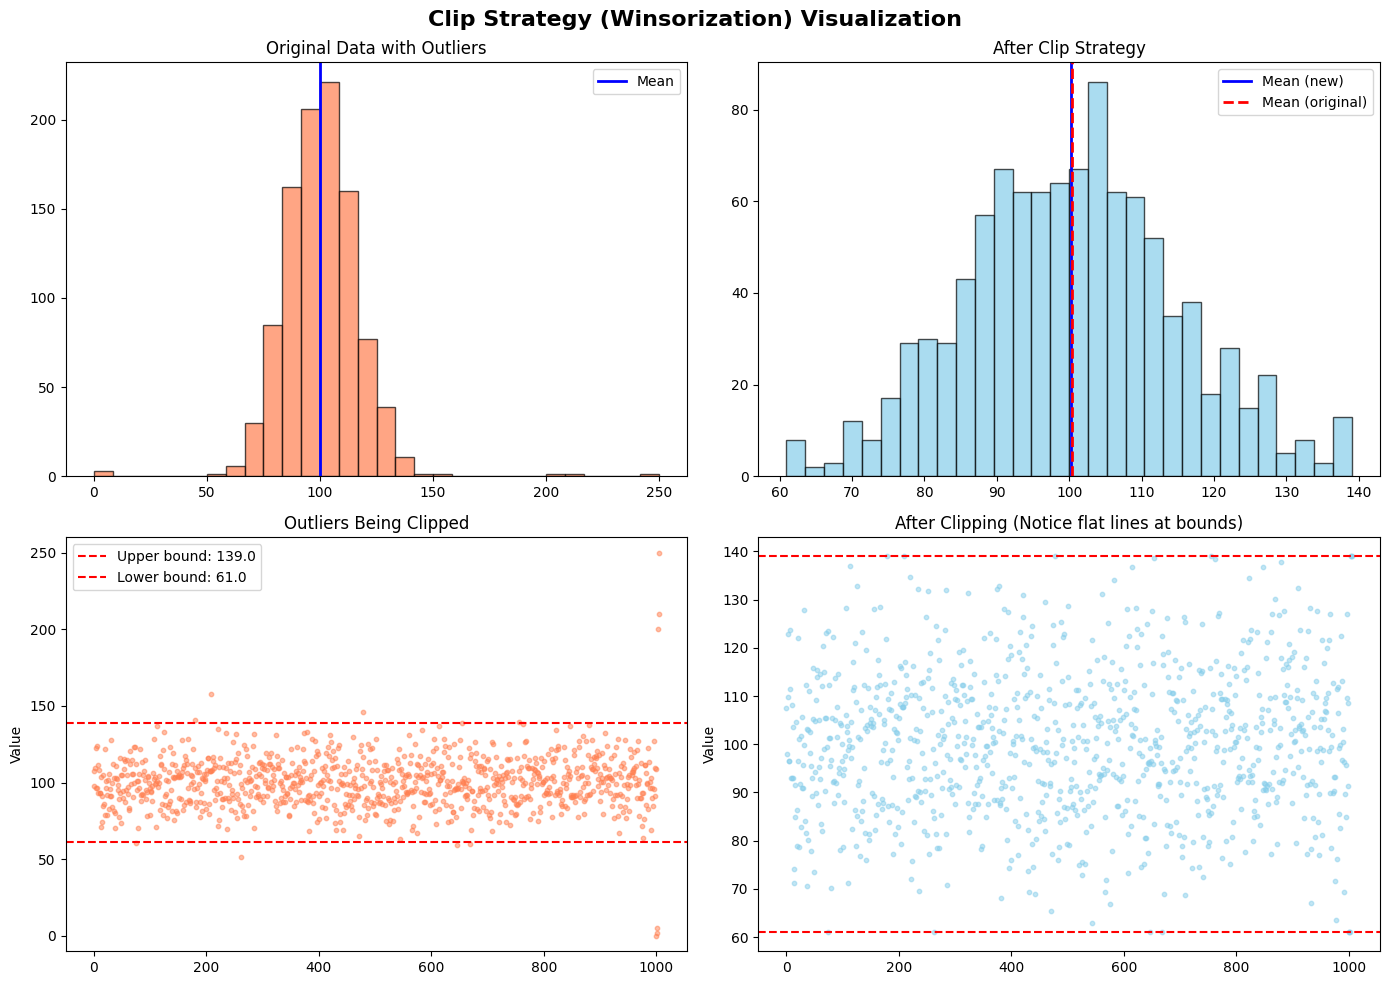

EFFECT OF CLIPPING ON VALUES
Value    0.0 →   61.0 (CLIPPED!)
Value   10.0 →   61.0 (CLIPPED!)
Value   50.0 →   61.0 (CLIPPED!)
Value  200.0 →  139.0 (CLIPPED!)
Value  250.0 →  139.0 (CLIPPED!)


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create sample data with outliers
np.random.seed(42)
normal_data = np.random.normal(100, 15, 1000)
outliers = [0, 2, 5, 200, 210, 250]  # Add some extreme values
data = np.concatenate([normal_data, outliers])

# Let's visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original data
axes[0,0].hist(data, bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[0,0].axvline(x=100, color='blue', linestyle='-', linewidth=2, label='Mean')
axes[0,0].set_title('Original Data with Outliers')
axes[0,0].legend()

# Calculate bounds using IQR
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Apply clipping
clipped_data = np.clip(data, lower_bound, upper_bound)

# Clipped data
axes[0,1].hist(clipped_data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0,1].axvline(x=np.mean(clipped_data), color='blue', linestyle='-', linewidth=2, label='Mean (new)')
axes[0,1].axvline(x=np.mean(data), color='red', linestyle='--', linewidth=2, label='Mean (original)')
axes[0,1].set_title('After Clip Strategy')
axes[0,1].legend()

# Show what happens to outliers
axes[1,0].scatter(range(len(data)), data, alpha=0.5, s=10, color='coral')
axes[1,0].axhline(y=upper_bound, color='red', linestyle='--', label=f'Upper bound: {upper_bound:.1f}')
axes[1,0].axhline(y=lower_bound, color='red', linestyle='--', label=f'Lower bound: {lower_bound:.1f}')
axes[1,0].set_title('Outliers Being Clipped')
axes[1,0].set_ylabel('Value')
axes[1,0].legend()
axes[1,0].set_ylim(min(data)-10, max(data)+10)

# Zoom in on clipping effect
axes[1,1].scatter(range(len(data)), clipped_data, alpha=0.5, s=10, color='skyblue')
axes[1,1].axhline(y=upper_bound, color='red', linestyle='--')
axes[1,1].axhline(y=lower_bound, color='red', linestyle='--')
axes[1,1].set_title('After Clipping (Notice flat lines at bounds)')
axes[1,1].set_ylabel('Value')

plt.suptitle('Clip Strategy (Winsorization) Visualization', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Show the effect on specific values
print("=" * 60)
print("EFFECT OF CLIPPING ON VALUES")
print("=" * 60)
extreme_values = np.array([0, 10, 50, 200, 250])
clipped = np.clip(extreme_values, lower_bound, upper_bound)

for original, clipped_val in zip(extreme_values, clipped):
    if original == clipped_val:
        print(f"Value {original:6.1f} → {clipped_val:6.1f} (unchanged)")
    else:
        print(f"Value {original:6.1f} → {clipped_val:6.1f} (CLIPPED!)")

** Comparison: Clip vs Other Strategies

In [50]:
# Let's compare all strategies with the same data
import pandas as pd
import numpy as np

data = pd.Series([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 100, 200, 500])

# Calculate bounds
Q1, Q3 = data.quantile([0.25, 0.75])
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("OUTLIER HANDLING STRATEGIES COMPARISON")
print("=" * 60)
print(f"Original data: {data.tolist()}")
print(f"Bounds: [{lower:.1f}, {upper:.1f}]")
print(f"Mean: {data.mean():.1f}, Median: {data.median():.1f}")
print()

# Strategy 1: Clip (Winsorize)
clip_data = data.clip(lower, upper)
print(f"1. CLIP:")
print(f"   Result: {clip_data.tolist()}")
print(f"   Mean: {clip_data.mean():.1f}")
print(f"   Note: Preserves all data points, caps extreme values")

# Strategy 2: Remove (set to NaN)
remove_data = data.copy()
remove_data[remove_data > upper] = np.nan
remove_data[remove_data < lower] = np.nan
print(f"\n2. REMOVE (set to NaN):")
print(f"   Result: {remove_data.tolist()}")
print(f"   Mean: {remove_data.mean():.1f}")
print(f"   Note: Creates missing values, reduces sample size")

# Strategy 3: Replace with Mean
mean_data = data.copy()
mean_val = data[(data >= lower) & (data <= upper)].mean()
mean_data[mean_data > upper] = mean_val
mean_data[mean_data < lower] = mean_val
print(f"\n3. REPLACE WITH MEAN:")
print(f"   Result: {mean_data.tolist()}")
print(f"   Mean: {mean_data.mean():.1f}")
print(f"   Note: Changes distribution shape")

# Strategy 4: Replace with Median
median_data = data.copy()
median_val = data[(data >= lower) & (data <= upper)].median()
median_data[median_data > upper] = median_val
median_data[median_data < lower] = median_val
print(f"\n4. REPLACE WITH MEDIAN:")
print(f"   Result: {median_data.tolist()}")
print(f"   Mean: {median_data.mean():.1f}")
print(f"   Note: More robust to outliers")

OUTLIER HANDLING STRATEGIES COMPARISON
Original data: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 100, 200, 500]
Bounds: [-5.0, 19.0]
Mean: 65.8, Median: 7.0

1. CLIP:
   Result: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 19, 19, 19]
   Mean: 8.6
   Note: Preserves all data points, caps extreme values

2. REMOVE (set to NaN):
   Result: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, nan, nan, nan]
   Mean: 5.5
   Note: Creates missing values, reduces sample size

3. REPLACE WITH MEAN:
   Result: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 5.5, 5.5, 5.5]
   Mean: 5.5
   Note: Changes distribution shape

4. REPLACE WITH MEDIAN:
   Result: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 5.5, 5.5, 5.5]
   Mean: 5.5
   Note: More robust to outliers


C:\Users\parsayan\AppData\Local\Temp\ipykernel_44932\3120342389.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '5.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  mean_data[mean_data > upper] = mean_val
C:\Users\parsayan\AppData\Local\Temp\ipykernel_44932\3120342389.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '5.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  median_data[median_data > upper] = median_val


*** When to use clip strategy:

    When you can't afford to lose data points

    For machine learning pipelines where outliers would distort models

    When outliers are likely measurement errors, not genuine extreme values

    When you want a conservative approach to outlier handling

The clip strategy essentially says: "These extreme values are probably wrong, but I'm not confident enough to completely remove them, so I'll just pull them back to the border of what's reasonable."

age: 215 outliers (0.4%)
fnlwgt: 1453 outliers (3.0%)
education-num: 1787 outliers (3.7%)
capital-gain: 4035 outliers (8.3%)
capital-loss: 2282 outliers (4.7%)
hours-per-week: 13486 outliers (27.6%)


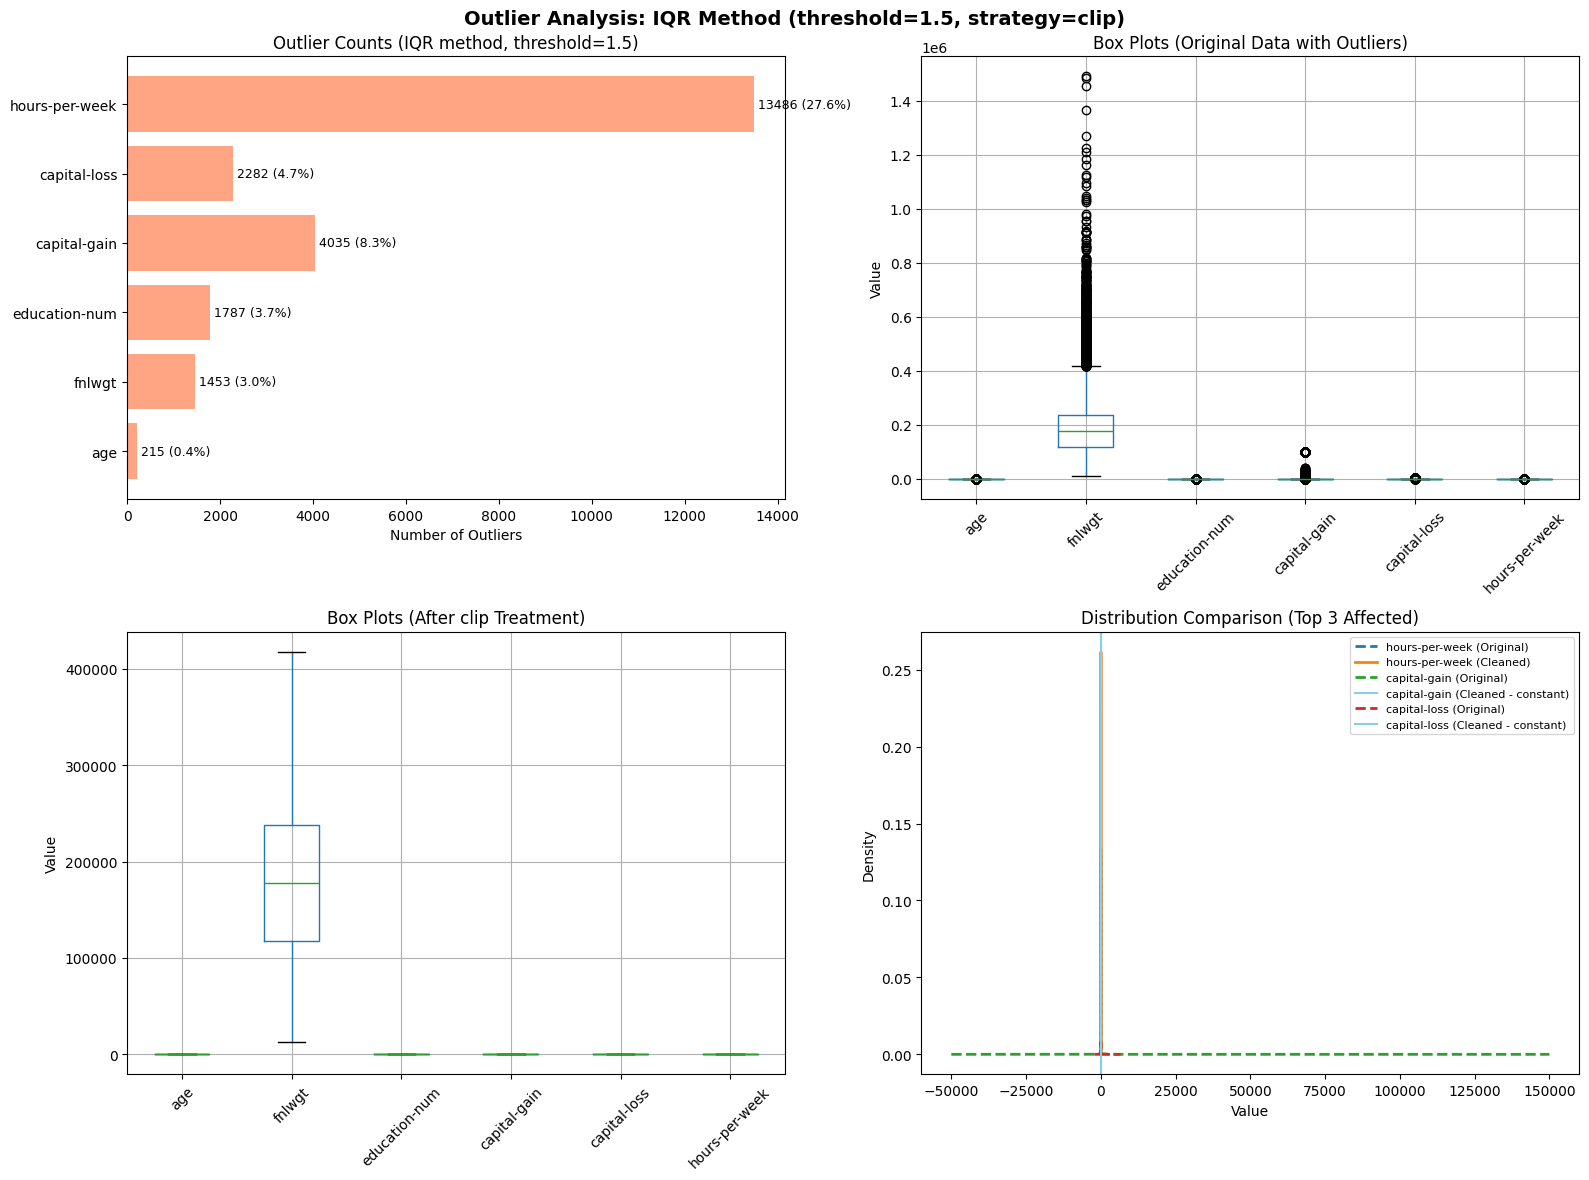

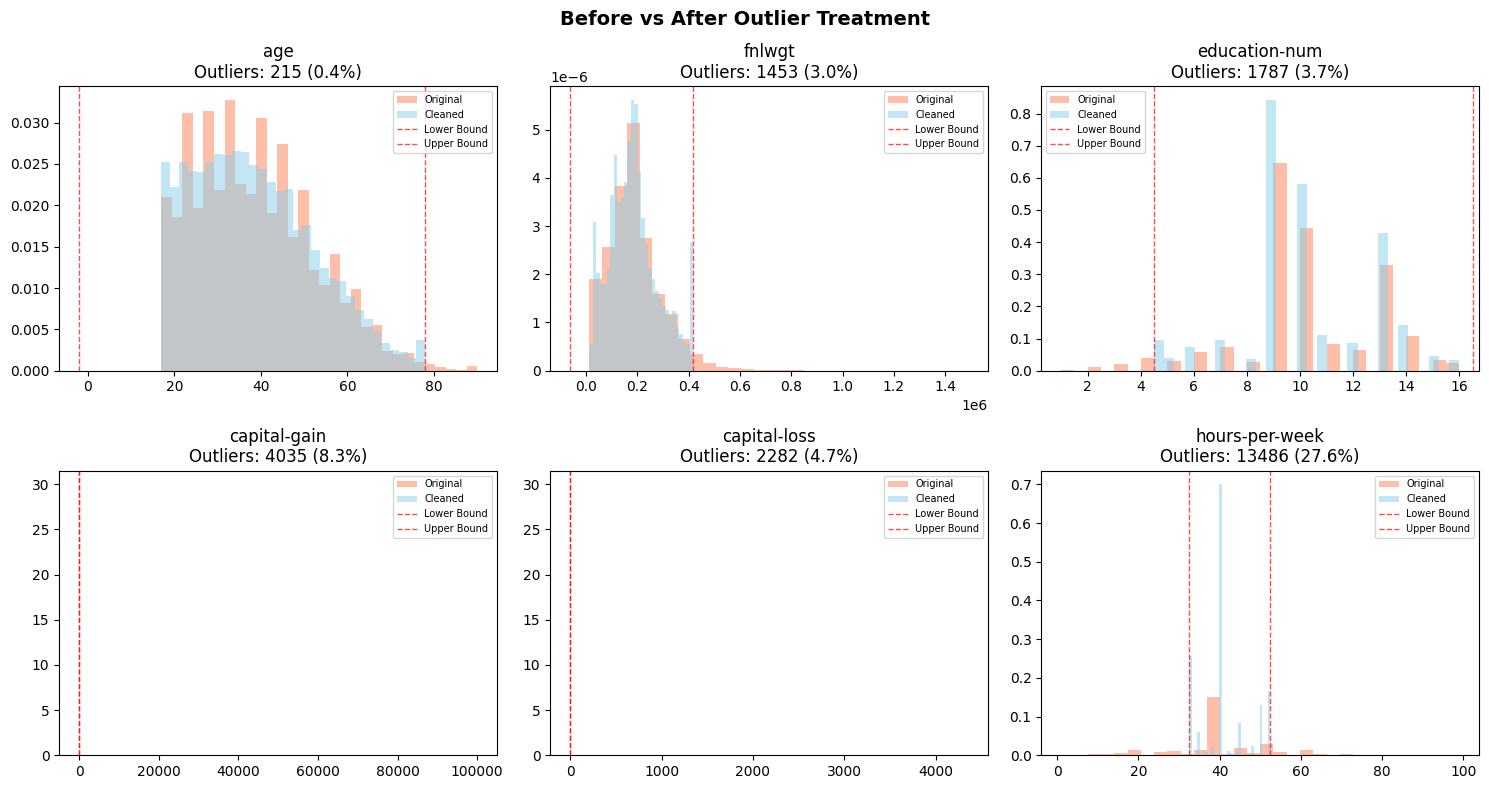


OUTLIER DETECTION SUMMARY
        Column  Outliers_Count Outliers_Pct Lower_Bound Upper_Bound
           age             215        0.44%       -2.00       78.00
        fnlwgt            1453        2.98%   -62521.88   417683.12
 education-num            1787        3.66%        4.50       16.50
  capital-gain            4035        8.27%         N/A         N/A
  capital-loss            2282        4.68%         N/A         N/A
hours-per-week           13486       27.64%       32.50       52.50
Original shape: (48790, 15)
Cleaned shape: (48790, 15)
Processing cleaned data: (48790, 15)


In [51]:
# Clean the outliers
df_clean_iqr, info_iqr = outlier_handler(
    df,
    method='iqr',
    threshold=1.5,
    strategy='clip',
    plot=True,
    verbose=True
)

# Now use df_clean_iqr in other functions
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean_iqr.shape}")

# Example: Use in other preprocessing steps
def process_cleaned_data(df_clean):
    """Use cleaned data for further processing"""
    # Your other operations here
    print(f"Processing cleaned data: {df_clean.shape}")
    
    # For example, normalize the cleaned data
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
    df_clean[numeric_cols] = scaler.fit_transform(df_clean[numeric_cols])
    
    return df_clean

# Pass the cleaned DataFrame
df_processed = process_cleaned_data(df_clean_iqr)

#### 7) Plots and Visualize to undrestand data -> Data VIZ

In [52]:
df_processed.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'class'],
      dtype='object')

#### 1- Bar plot:

A bar chart is a graphical representation used to display and compare discrete categories of data through rectangular bars, where the length or height of each bar is proportional to the frequency or value of the corresponding category.

##### Compare Education level and related Income(over 50k):

* Calculate Proportions by Group:

C:\Users\parsayan\AppData\Local\Temp\ipykernel_44932\1622693880.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_proportions = df_processed.groupby('education')['class'].apply(


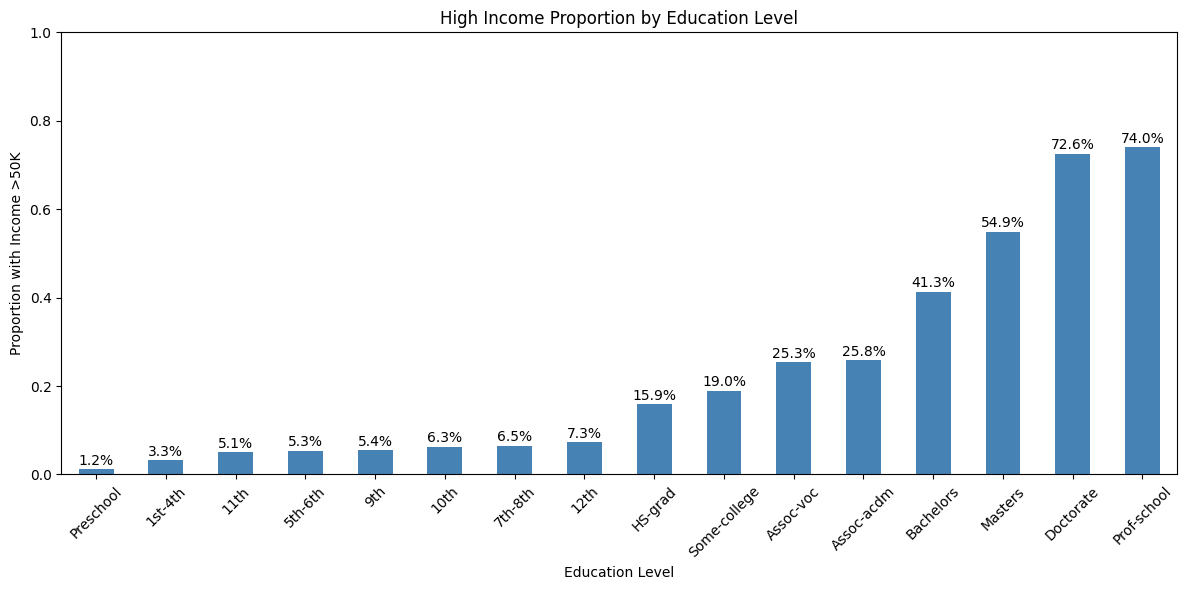

In [53]:
# Get proportions of high income by education
income_proportions = df_processed.groupby('education')['class'].apply(
    lambda x: (x == '>50K').mean()
).sort_values()

plt.figure(figsize=(12, 6))
income_proportions.plot(kind='bar', color='steelblue')
plt.xlabel('Education Level')
plt.ylabel('Proportion with Income >50K')
plt.title('High Income Proportion by Education Level')
plt.xticks(rotation=45)
plt.ylim(0, 1)
for i, v in enumerate(income_proportions):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center')
plt.tight_layout()
plt.show()

#### Compare income in men and women by same education level:

* Grouped Bar Chart (Best for Comparison): Interactive with Plotly(Best for Exploration):

In [54]:
import plotly.express as px

df_processed = outlier_handler(df, method='iqr', strategy='clip', plot=False, verbose=False)[0]
# 2. Check what columns exist
print("Available columns:", df_processed.columns.tolist())

# 3. Create income_numeric if it doesn't exist
if 'income_numeric' not in df_processed.columns:
    print("Creating income_numeric...")
    # Convert income to binary numeric
    df_processed['income_numeric'] = (df_processed['class'].astype(str).str.strip() == '>50K').astype(int)

# Prepare data

plot_data = df_processed.groupby(['education', 'sex'])['income_numeric'].mean().reset_index()

# Create interactive grouped bar chart
fig = px.bar(plot_data, 
             x='education', 
             y='income_numeric', 
             color='sex',
             barmode='group',
             title='High Income Proportion by Education and Gender',
             labels={'income_numeric': 'Proportion earning >50K', 
                    'education': 'Education Level'},
             color_discrete_map={'Male': 'steelblue', 'Female': 'salmon'},
             text_auto='.1%')

fig.update_layout(xaxis_tickangle=-45)
fig.show()

Available columns: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'class']
Creating income_numeric...


C:\Users\parsayan\AppData\Local\Temp\ipykernel_44932\868866910.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_data = df_processed.groupby(['education', 'sex'])['income_numeric'].mean().reset_index()


* Using Matplotlib with Custom Colors and Annotations

#### A Complete Compare with a table of report:

Available columns: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'class']
Creating income_numeric...


C:\Users\parsayan\AppData\Local\Temp\ipykernel_44932\1146029679.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_data = df_processed.groupby(['education', 'sex'])['income_numeric'].mean().reset_index()
C:\Users\parsayan\AppData\Local\Temp\ipykernel_44932\1146029679.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_data = df_processed.groupby(['education', 'sex'])['income_numeric'].mean().unstack()


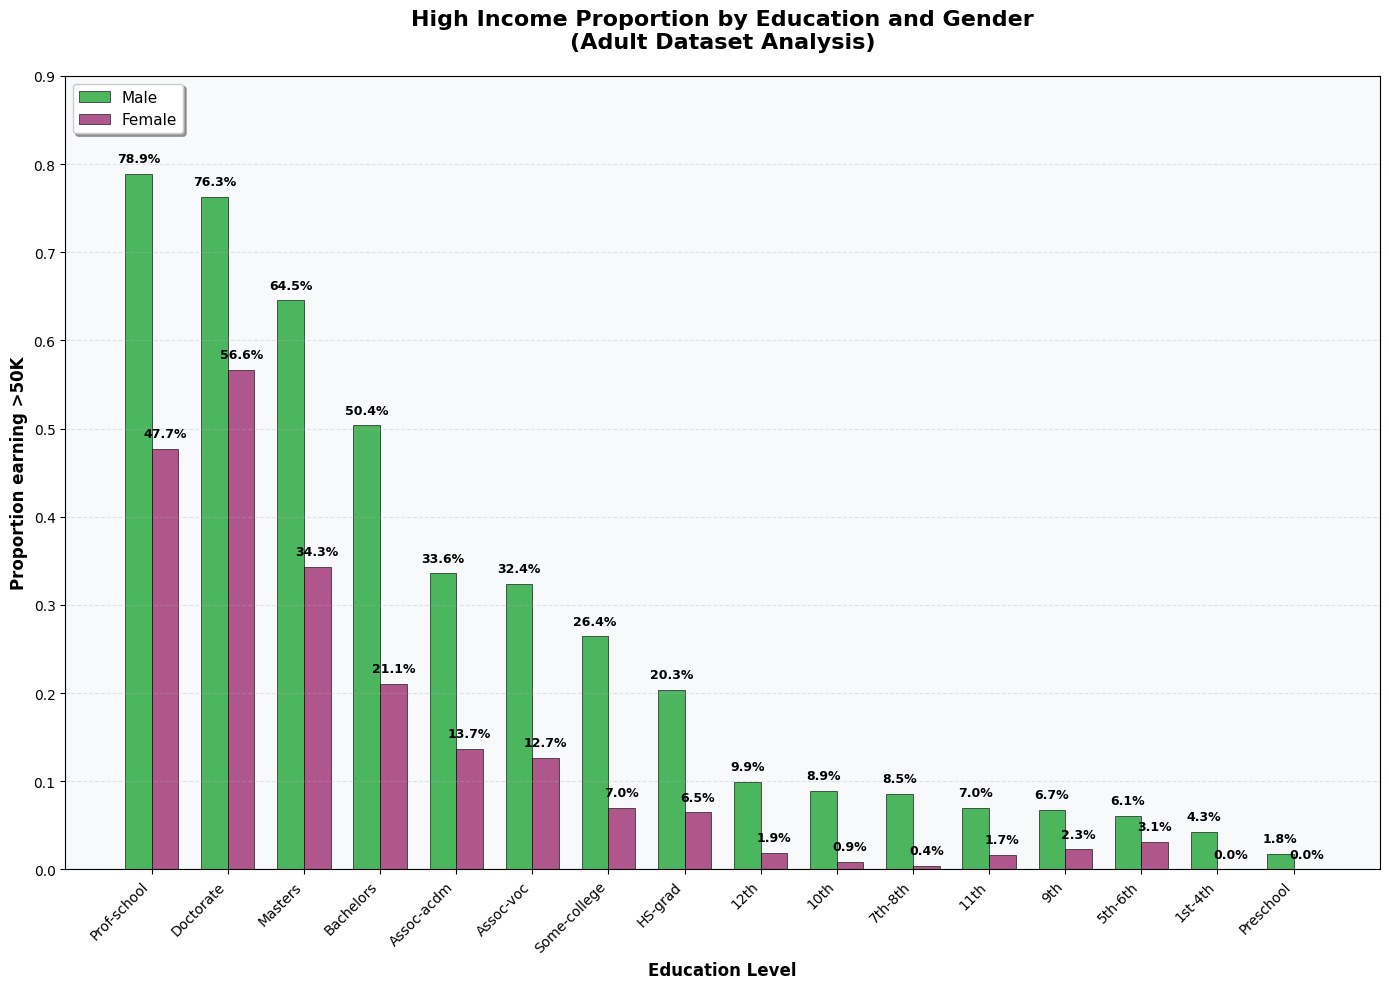

C:\Users\parsayan\AppData\Local\Temp\ipykernel_44932\1146029679.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  'Total Sample': df.groupby('education').size().values,
C:\Users\parsayan\AppData\Local\Temp\ipykernel_44932\1146029679.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  'Male Count': df[df['sex'] == 'Male'].groupby('education').size().values,
C:\Users\parsayan\AppData\Local\Temp\ipykernel_44932\1146029679.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True 


📊 INCOME ANALYSIS REPORT BY EDUCATION AND GENDER

📌 Dataset: Adult Income Dataset
📌 Target: Proportion earning >50K per year
📌 Total records: 48,790
📌 Education levels: 16

SUMMARY TABLE: High Income Proportion (>50K)
Education Level  Male (%)  Female (%)  Gender Gap (%)  Total Sample  Male Count  Female Count Gap Direction
           10th       8.9         0.9             8.0          8013        5540          2473   Men > Women
           11th       7.0         1.7             5.3         15770       10676          5094   Men > Women
           12th       9.9         1.9             8.0          2060        1326           734   Men > Women
        1st-4th       4.3         0.0             4.3           834         702           132   Men > Women
        5th-6th       6.1         3.1             2.9            81          57            24   Men > Women
        7th-8th       8.5         0.4             8.1           594         481           113   Men > Women
            9th       6.7

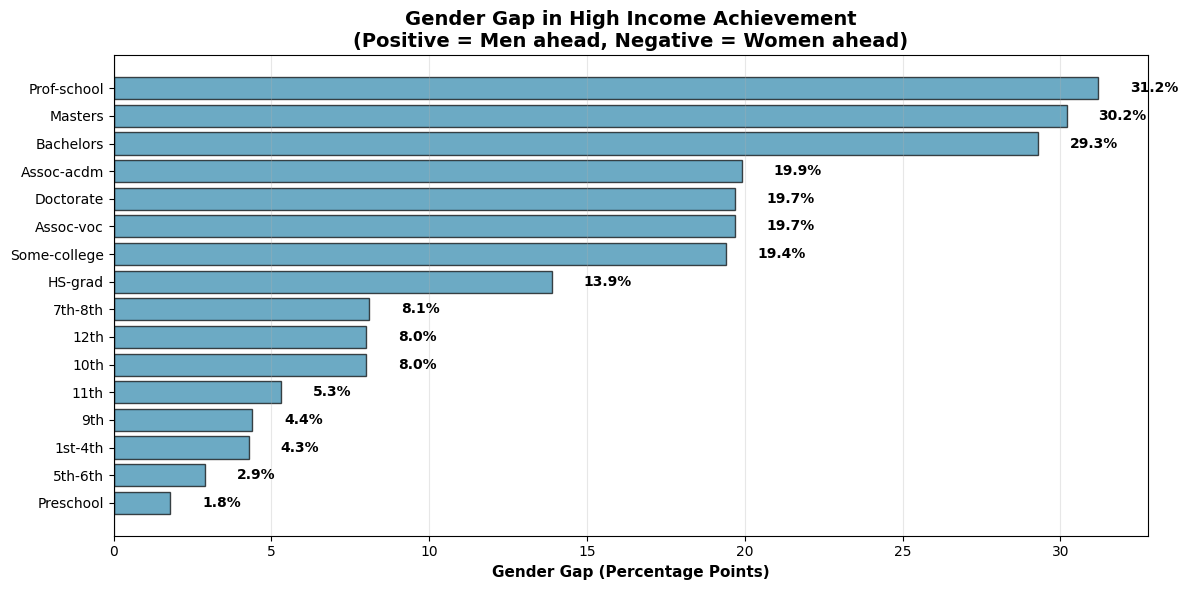


DETAILED STATISTICS BY EDUCATION LEVEL

─────────────────────────────────────────────────────────────────────────────────────
Education Level                                Male     Female        Gap   Sample
─────────────────────────────────────────────────────────────────────────────────────
10th                                           8.9%       0.9%       8.0%    8,013
11th                                           7.0%       1.7%       5.3%   15,770
12th                                           9.9%       1.9%       8.0%    2,060
1st-4th                                        4.3%       0.0%       4.3%      834
5th-6th                                        6.1%       3.1%       2.9%       81
7th-8th                                        8.5%       0.4%       8.1%      594
9th                                            6.7%       2.3%       4.4%    2,656
Assoc-acdm                                    33.6%      13.7%      19.9%      507
Assoc-voc                               

In [55]:
# Assuming that dataframe is 'df' with columns: 'education', 'sex', 'income'

df_processed = outlier_handler(df, method='iqr', strategy='clip', plot=False, verbose=False)[0]
# 2. Check what columns exist
print("Available columns:", df_processed.columns.tolist())

# 3. Create income_numeric if it doesn't exist
if 'income_numeric' not in df_processed.columns:
    print("Creating income_numeric...")
    # Convert income to binary numeric
    df_processed['income_numeric'] = (df_processed['class'].astype(str).str.strip() == '>50K').astype(int)

# Prepare data

plot_data = df_processed.groupby(['education', 'sex'])['income_numeric'].mean().reset_index()


# Calculate the data
pivot_data = df_processed.groupby(['education', 'sex'])['income_numeric'].mean().unstack()

# Sort by male proportion for better visualization
pivot_data = pivot_data.sort_values('Male', ascending=False)

# Create the plot
fig, ax = plt.subplots(figsize=(14, 10))

x = np.arange(len(pivot_data.index))
width = 0.35

# Create bars with beautiful colors
male_bars = ax.bar(x - width/2, pivot_data['Male'], width, 
                   label='Male', color="#2EAB43", edgecolor='black', linewidth=0.5, alpha=0.85)
female_bars = ax.bar(x + width/2, pivot_data['Female'], width, 
                     label='Female', color="#A23B7A", edgecolor='black', linewidth=0.5, alpha=0.85)

# Customize the plot
ax.set_xlabel('Education Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Proportion earning >50K', fontsize=12, fontweight='bold')
ax.set_title('High Income Proportion by Education and Gender\n(Adult Dataset Analysis)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(pivot_data.index, rotation=45, ha='right', fontsize=10)
ax.legend(loc='upper left', fontsize=11, frameon=True, fancybox=True, shadow=True)
ax.set_ylim(0, 0.9)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on top of bars with custom formatting
for bars in [male_bars, female_bars]:
    for bar in bars:
        height = bar.get_height()
        if not pd.isna(height):
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{height:.1%}', ha='center', va='bottom', fontsize=9, 
                   fontweight='bold', color='black')

# Add a subtle background color
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.show()

# ============================================
# CREATE COMPREHENSIVE SUMMARY TABLE
# ============================================

# Create a detailed summary table
summary_table = pd.DataFrame({
    'Education Level': pivot_data.index,
    'Male (%)': (pivot_data['Male'] * 100).round(1),
    'Female (%)': (pivot_data['Female'] * 100).round(1),
    'Gender Gap (%)': ((pivot_data['Male'] - pivot_data['Female']) * 100).round(1),
    'Total Sample': df.groupby('education').size().values,
    'Male Count': df[df['sex'] == 'Male'].groupby('education').size().values,
    'Female Count': df[df['sex'] == 'Female'].groupby('education').size().values
})

# Add a column indicating if gap is significant
summary_table['Gap Direction'] = summary_table['Gender Gap (%)'].apply(
    lambda x: 'Men > Women' if x > 0 else ('Women > Men' if x < 0 else 'Equal')
)

# Sort by education level for better readability
summary_table = summary_table.sort_values('Education Level')

# Calculate additional statistics
avg_male = summary_table['Male (%)'].mean()
avg_female = summary_table['Female (%)'].mean()
avg_gap = summary_table['Gender Gap (%)'].mean()

# ============================================
# PRINT BEAUTIFUL FORMATTED TABLE
# ============================================

print("\n" + "="*80)
print("📊 INCOME ANALYSIS REPORT BY EDUCATION AND GENDER")
print("="*80)
print(f"\n📌 Dataset: Adult Income Dataset")
print(f"📌 Target: Proportion earning >50K per year")
print(f"📌 Total records: {len(df):,}")
print(f"📌 Education levels: {len(pivot_data)}")

print("\n" + "="*80)
print("SUMMARY TABLE: High Income Proportion (>50K)")
print("="*80)

# Display the main table with formatting
print(summary_table.to_string(index=False))

print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)

# Find top and bottom performing groups
top_edu = summary_table.loc[summary_table['Male (%)'].idxmax(), 'Education Level']
bottom_edu = summary_table.loc[summary_table['Male (%)'].idxmin(), 'Education Level']
largest_gap_edu = summary_table.loc[summary_table['Gender Gap (%)'].abs().idxmax(), 'Education Level']
smallest_gap_edu = summary_table.loc[summary_table['Gender Gap (%)'].abs().idxmin(), 'Education Level']

print(f"\n🎯 Top performing education (Male): {top_edu}")
print(f"🎯 Bottom performing education (Male): {bottom_edu}")
print(f"\n📈 Largest gender gap: {largest_gap_edu} ({summary_table.loc[summary_table['Education Level'] == largest_gap_edu, 'Gender Gap (%)'].values[0]:.1f}% difference)")
print(f"📉 Smallest gender gap: {smallest_gap_edu} ({summary_table.loc[summary_table['Education Level'] == smallest_gap_edu, 'Gender Gap (%)'].values[0]:.1f}% difference)")
print(f"\n👥 Average male success rate: {avg_male:.1f}%")
print(f"👥 Average female success rate: {avg_female:.1f}%")
print(f"📊 Average gender gap: {avg_gap:.1f}%")

# ============================================
# ADDITIONAL VISUALIZATION: Gap Analysis Chart
# ============================================

fig2, ax2 = plt.subplots(figsize=(12, 6))

# Create horizontal bar chart for gender gap
gap_data = summary_table.set_index('Education Level')['Gender Gap (%)'].sort_values()

colors_gap = ['#2E86AB' if x > 0 else '#A23B59' if x < 0 else '#808080' for x in gap_data.values]
bars = ax2.barh(range(len(gap_data)), gap_data.values, color=colors_gap, alpha=0.7, edgecolor='black')

ax2.set_yticks(range(len(gap_data)))
ax2.set_yticklabels(gap_data.index)
ax2.set_xlabel('Gender Gap (Percentage Points)', fontsize=11, fontweight='bold')
ax2.set_title('Gender Gap in High Income Achievement\n(Positive = Men ahead, Negative = Women ahead)', 
              fontsize=14, fontweight='bold')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax2.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, gap) in enumerate(zip(bars, gap_data.values)):
    ax2.text(gap + (1 if gap >= 0 else -1), bar.get_y() + bar.get_height()/2,
            f'{gap:.1f}%', va='center', ha='left' if gap >= 0 else 'right', fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# EXPORT TO CSV (Optional)
# ============================================

# Uncomment to save the report
# summary_table.to_csv('income_analysis_report.csv', index=False)
# print("\n✅ Report saved as 'income_analysis_report.csv'")

# ============================================
# PRINT RAW STATISTICS FOR VERIFICATION
# ============================================

print("\n" + "="*80)
print("DETAILED STATISTICS BY EDUCATION LEVEL")
print("="*80)

# Simplified console table
print("\n" + "─"*85)
print(f"{'Education Level':<40} {'Male':>10} {'Female':>10} {'Gap':>10} {'Sample':>8}")
print("─"*85)

for _, row in summary_table.iterrows():
    print(f"{row['Education Level']:<40} {row['Male (%)']:>9.1f}% {row['Female (%)']:>9.1f}% {row['Gender Gap (%)']:>9.1f}% {row['Total Sample']:>8,}")

print("─"*85)
print(f"{'AVERAGE':<40} {avg_male:>9.1f}% {avg_female:>9.1f}% {avg_gap:>9.1f}%")
print("─"*85)

#### 2- Line Chart: 

Proper to show trends. Usually, the x_axis is showed time, date, sequence,... Sometimes use it to show distribution od discrete numeric (int) data.

##### Age Distribution:

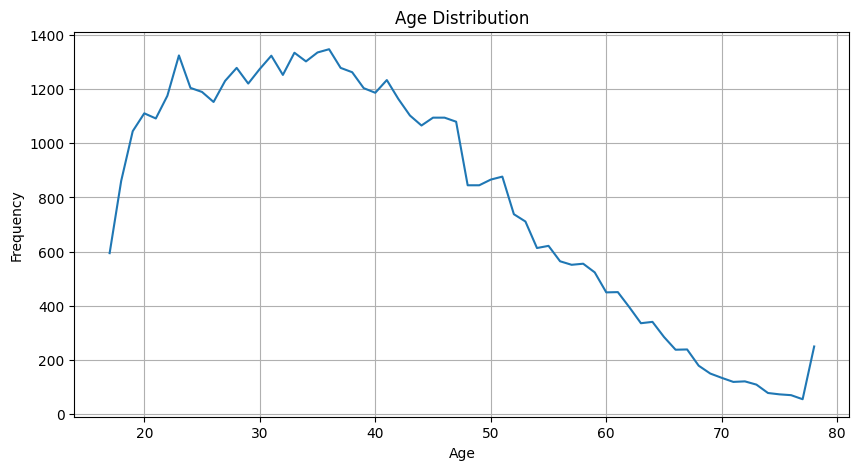

In [56]:
# Line Chart for "age" - By Pandas Plot
df_processed = outlier_handler(df, method='iqr', strategy='clip', plot=False, verbose=False)[0]
age_count = df_processed['age'].value_counts().sort_index()
age_count.plot(
    kind='line',
    figsize=(10, 5),
    grid=True,
            )
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


##### Relationship Distribution:

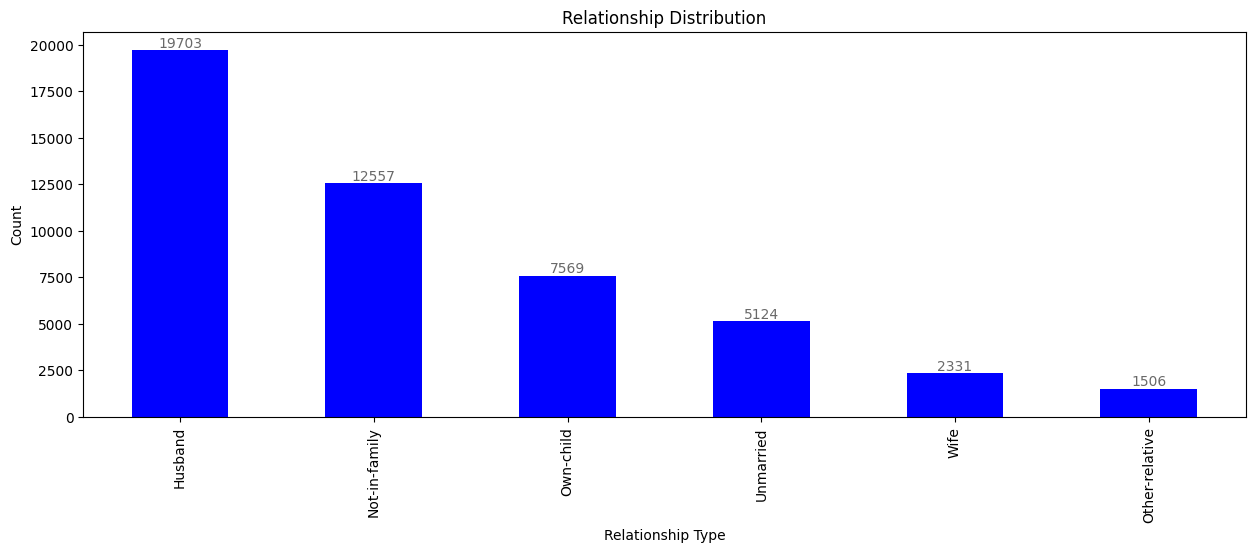

In [57]:
# Assuming df id your DataFrame
plt.figure(figsize=(15, 5))
df_processed = outlier_handler(df, method='iqr', strategy='clip', plot=False, verbose=False)[0]
relationship_counts = df_processed['relationship'].value_counts()
ax = relationship_counts.plot(
    kind='bar',
    color='b',
            )
plt.title('Relationship Distribution')
plt.xlabel('Relationship Type')
plt.ylabel('Count')

# Add text to label above bars --> with ".text"
for i in ax.patches:
    # get_x pulls left or right; get_height pushes up or down
    ax.text(
        i.get_x() + i.get_width() / 2.,
        i.get_height() + 0.3,
        str(i.get_height()),
        fontsize=10,
        color='dimgrey',
        ha='center',  # Horizontal Allignment
        va='bottom',  # Vertical Allignment
        )
plt.show()


#### Line chart in seaborn package:

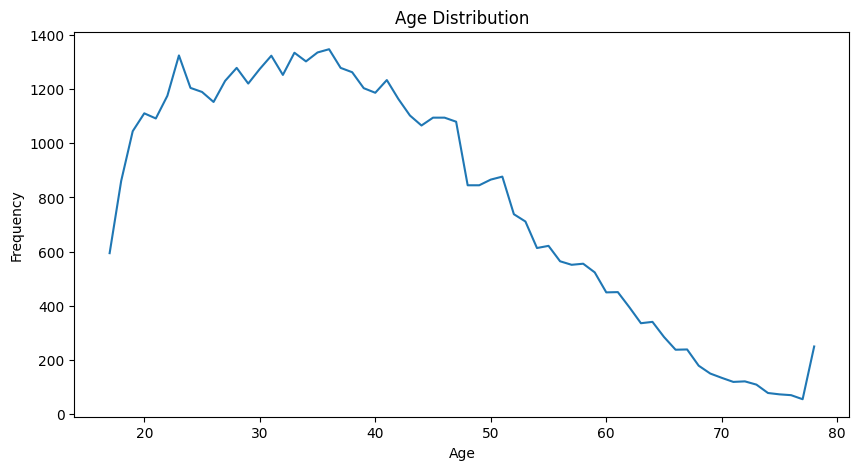

In [58]:
# Age Distribution By seaborn

plt.figure(figsize=(10, 5))
sns.lineplot(
    x=age_count.index,
    y=age_count.values,
    data=pd.DataFrame(age_count),
            )
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


- plotly has 2 packages(most use and attractive): 

1) plotly.express as px  

2) plotly.graph_objects as go (more advanced)

In [ ]:
%pip install --upgrade nbformat ipykernel

#### Age Distribution By plotly --> interactive dashboards

In [59]:
import plotly.io as pio

fig = px.line(
    age_count,
    x=age_count.index,
    y=age_count.values,
            )                  
fig.update_layout(
    title='Age Distribution',
    xaxis_title= 'Age',
    yaxis_title= 'Frequency',
                )
fig.update_traces(
    hoverinfo='all',
    hovertemplate='<b> Age: </b> %{x}<br><i> frequency: </i> %{y}' 
                )   # <b> --> bold, close with </b> / <br> --> break(inter line below) / <i> --> italic, close with </i>
fig.show()


#### Age Distribution By bokeh --> has very pretty and vary visualization formats/ interactive dashboards

In [60]:
output_notebook() # to show in this notebook frame
fig = figure(
    title='Age Distribution',
    x_axis_label='Age',
    y_axis_label='Frequency',
    width=800,
    height=400,
            )
fig.line(
    x=age_count.index,
    y=age_count.values,
    line_width=2,
        )

hover = HoverTool() 
hover.tooltips = [
    ('age', '@x'),
    ('frequency', '@y'),
                 ]
fig.add_tools(hover)
show(fig)


Loading BokehJS ...

**Bar Chart:

Not suitable for high counts of bars, and most useful to categorical data.

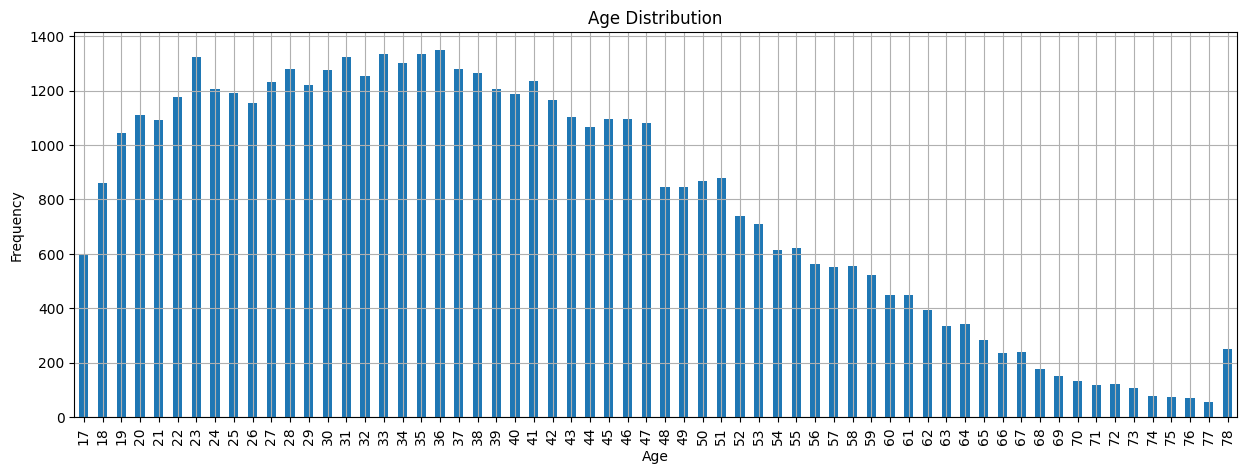

In [61]:
# plt.figure(figsize=(15, 5))
# plt.bar(age_count.index, age_count.values)
age_count.plot(
    kind='bar',
    figsize=(15, 5),
    grid=True,
            )

# age_count.plot(kind='barh', figsize=(15, 5), grid=True) --> horizental bar chart
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


In [54]:
df_processed.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'class'],
      dtype='object')

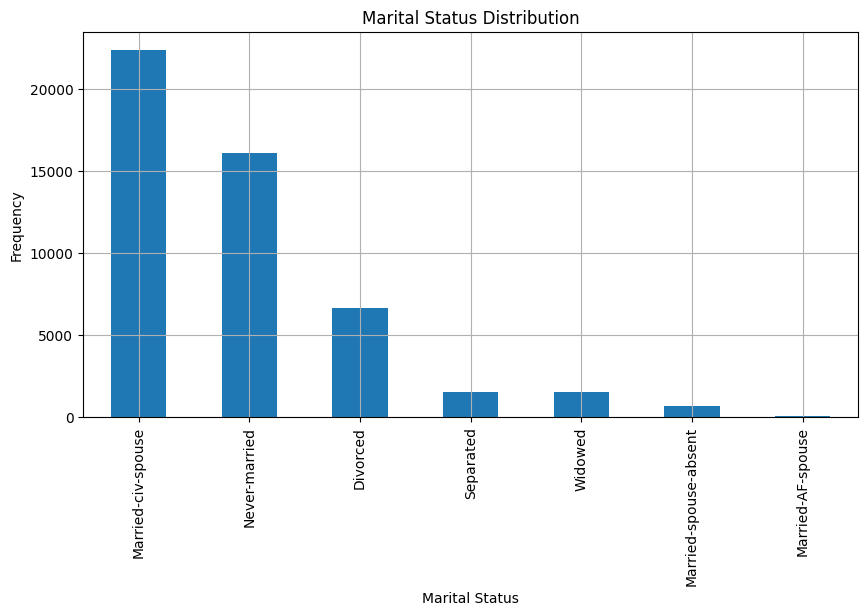

In [62]:
# Marital Status - Bar Chart
df_processed = outlier_handler(df, method='iqr', strategy='clip', plot=False, verbose=False)[0]
marital_count = df_processed['marital-status'].value_counts()
marital_count.plot(
    kind='bar',
    figsize=(10, 5),
    grid=True,
                )

plt.title('Marital Status Distribution')
plt.xlabel('Marital Status')
plt.ylabel('Frequency')
plt.show()


#### 3- Histogram: 

A histogram is a visual representation of the distribution of quantitative data.

* One column has to changed by name:

In [71]:
# First, check what columns you actually have
print("Current columns:", df_processed.columns.tolist())

# Find the target/income column
target_columns = [col for col in df_processed.columns if any(
    term in col.lower() for term in ['income', 'class', 'target', 'salary', '>50k', '<=50k']
)]
print(f"Possible target columns: {target_columns}")

# Assuming the target column is 'class' (common in UCI Adult dataset)
# Rename it properly
if 'class' in df_processed.columns:
    df_processed.rename(columns={'class': 'income'}, inplace=True)
    print("✓ Renamed 'class' to 'income'")
elif 'income' not in df_processed.columns and target_columns:
    # Use the first found target column
    old_name = target_columns[0]
    df_processed.rename(columns={old_name: 'income'}, inplace=True)
    print(f"✓ Renamed '{old_name}' to 'income'")

Current columns: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'class']
Possible target columns: ['workclass', 'class']
✓ Renamed 'class' to 'income'


In [72]:
# Print exact column names with visible whitespace
print("Actual column names:")
for i, col in enumerate(df_processed.columns):
    print(f"  [{i}] '{col}' (length: {len(col)})")

# Check if 'income' exists (with possible whitespace variations)
income_cols = [col for col in df_processed.columns if 'income' in col.lower()]
print(f"\nColumns containing 'income': {income_cols}")

# Check if 'class' still exists
class_cols = [col for col in df_processed.columns if 'class' in col.lower()]
print(f"Columns containing 'class': {class_cols}")

# Print first few rows
print("\nFirst 2 rows:")
print(df_processed.head(2))

Actual column names:
  [0] 'age' (length: 3)
  [1] 'workclass' (length: 9)
  [2] 'fnlwgt' (length: 6)
  [3] 'education' (length: 9)
  [4] 'education-num' (length: 13)
  [5] 'marital-status' (length: 14)
  [6] 'occupation' (length: 10)
  [7] 'relationship' (length: 12)
  [8] 'race' (length: 4)
  [9] 'sex' (length: 3)
  [10] 'capital-gain' (length: 12)
  [11] 'capital-loss' (length: 12)
  [12] 'hours-per-week' (length: 14)
  [13] 'native-country' (length: 14)
  [14] 'income' (length: 6)

Columns containing 'income': ['income']
Columns containing 'class': ['workclass']

First 2 rows:
   age workclass    fnlwgt education  education-num      marital-status  \
0   25   Private  226802.0      11th            7.0       Never-married   
1   38   Private   89814.0   HS-grad            9.0  Married-civ-spouse   

          occupation relationship   race   sex  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black  Male             0             0   
1    Farming-fishing      Husb

In [73]:
# Test the column changing name:
df_processed = df_processed.rename(columns={'class': 'income'})

# Verify IMMEDIATELY
print("AFTER RENAME:")
print(f"Last 3 columns: {df_processed.columns[-3:].tolist()}")
print(f"'income' in columns: {'income' in df_processed.columns}")
print(f"'class' in columns: {'class' in df_processed.columns}")

# Test the column access
try:
    test = df_processed[['sex', 'hours-per-week', 'income']]
    print("\n✓ Column access successful!")
    print(f"Shape: {test.shape}")
except KeyError as e:
    print(f"\n✗ Column access failed: {e}")
    print("Available columns:", df_processed.columns.tolist())

AFTER RENAME:
Last 3 columns: ['hours-per-week', 'native-country', 'income']
'income' in columns: True
'class' in columns: False

✓ Column access successful!
Shape: (48790, 3)


C:\Users\parsayan\AppData\Local\Temp\ipykernel_44932\3631194635.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(box_data, labels=['Male', 'Female'], patch_artist=True)


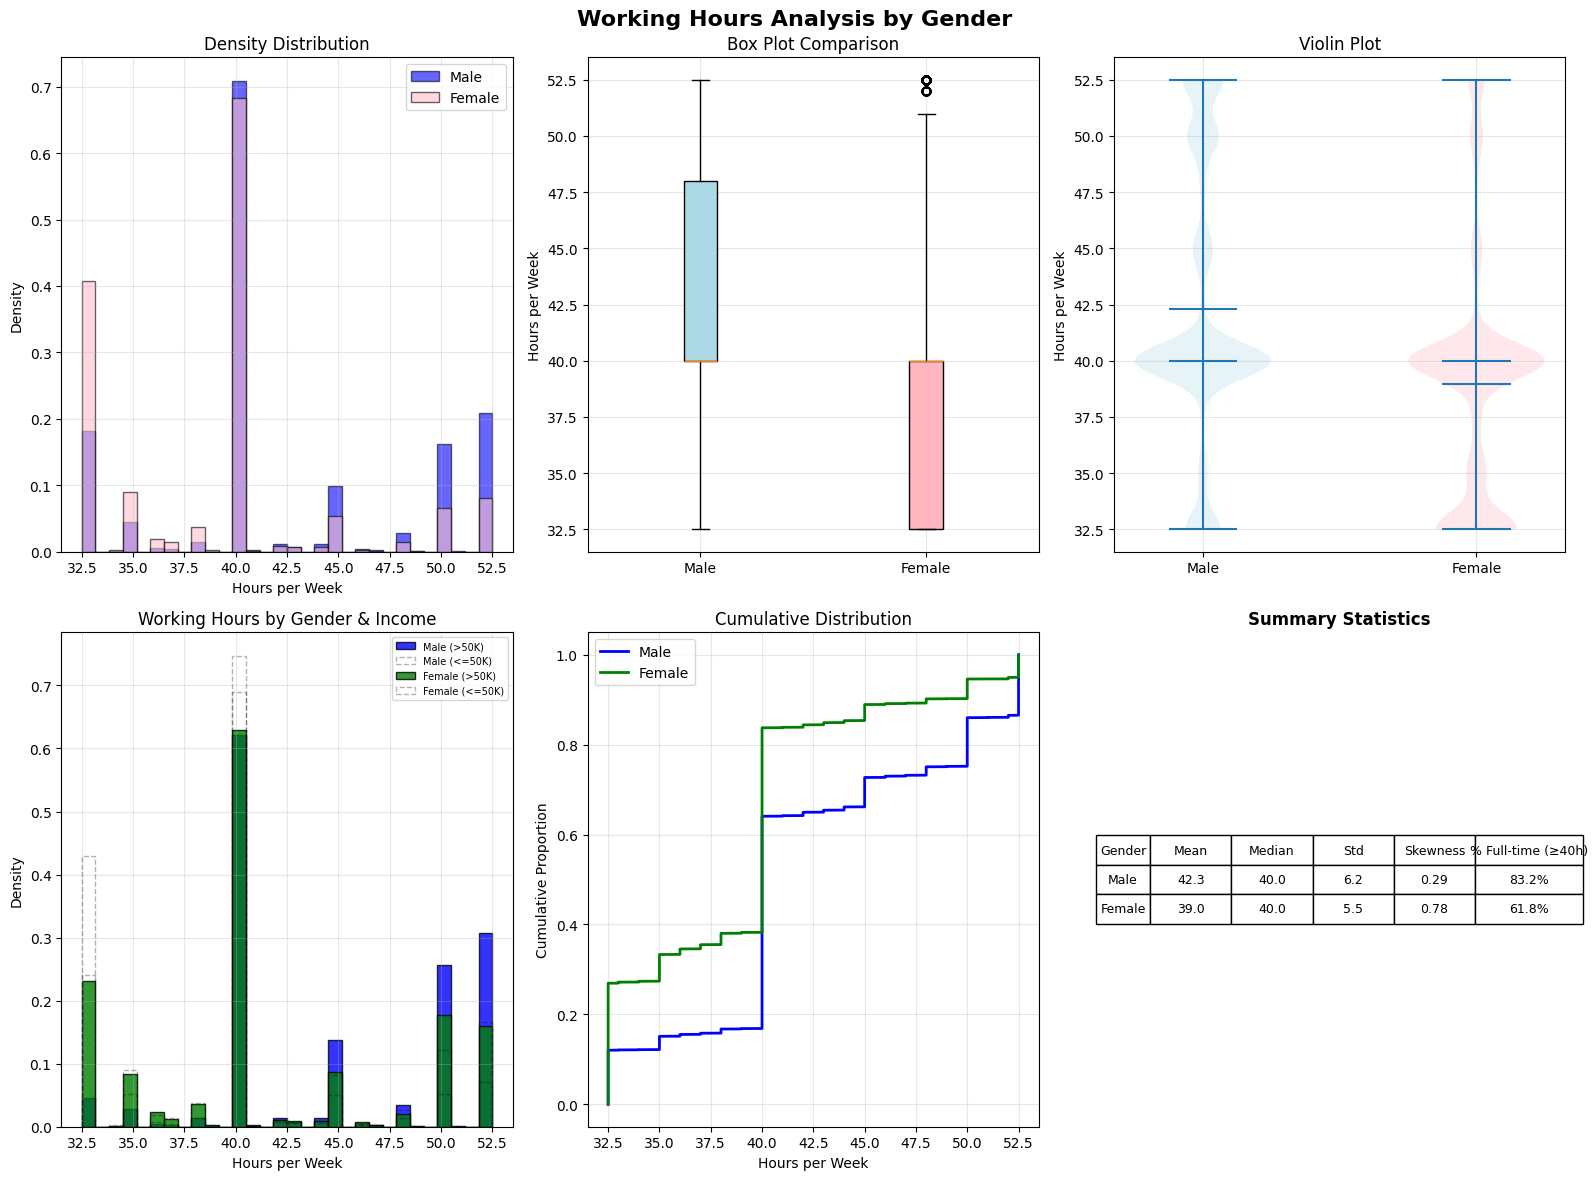


DETAILED STATISTICS: WORKING HOURS BY GENDER
          count       mean       std   min   25%   50%   75%   max
sex                                                               
Female  16176.0  38.956324  5.538640  32.5  32.5  40.0  40.0  52.5
Male    32614.0  42.304210  6.189598  32.5  40.0  40.0  48.0  52.5

FULL-TIME VS PART-TIME BY GENDER
full_time  False  True
sex                   
Female      38.2  61.8
Male        16.8  83.2
All         23.9  76.1


In [74]:
def plot_gender_working_hours_analysis(df):
    """
    Comprehensive visualization of working hours by gender
    """
    # Clean the data
   
    work_data = df[['sex', 'hours-per-week', 'income']].copy()
    work_data = work_data.dropna()
    
    # Clean sex column if needed
    work_data['sex'] = work_data['sex'].str.strip()
    
    # Create figure with subplots
    fig = plt.figure(figsize=(16, 12))
    
    # 1. Main histogram comparison
    ax1 = plt.subplot(2, 3, 1)
    ax1.hist(work_data[work_data['sex'] == 'Male']['hours-per-week'], 
             bins=30, alpha=0.6, color='blue', label='Male', density=True, edgecolor='black')
    ax1.hist(work_data[work_data['sex'] == 'Female']['hours-per-week'], 
             bins=30, alpha=0.6, color='pink', label='Female', density=True, edgecolor='black')
    ax1.set_title('Density Distribution')
    ax1.set_xlabel('Hours per Week')
    ax1.set_ylabel('Density')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Box plot
    ax2 = plt.subplot(2, 3, 2)
    box_data = [work_data[work_data['sex'] == 'Male']['hours-per-week'].dropna(),
                work_data[work_data['sex'] == 'Female']['hours-per-week'].dropna()]
    bp = ax2.boxplot(box_data, labels=['Male', 'Female'], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('lightpink')
    ax2.set_title('Box Plot Comparison')
    ax2.set_ylabel('Hours per Week')
    ax2.grid(True, alpha=0.3)
    
    # 3. Violin plot
    ax3 = plt.subplot(2, 3, 3)
    violin_data = [work_data[work_data['sex'] == 'Male']['hours-per-week'].dropna(),
                   work_data[work_data['sex'] == 'Female']['hours-per-week'].dropna()]
    vp = ax3.violinplot(violin_data, positions=[1, 2], showmeans=True, showmedians=True)
    vp['bodies'][0].set_facecolor('lightblue')
    vp['bodies'][1].set_facecolor('lightpink')
    ax3.set_xticks([1, 2])
    ax3.set_xticklabels(['Male', 'Female'])
    ax3.set_title('Violin Plot')
    ax3.set_ylabel('Hours per Week')
    ax3.grid(True, alpha=0.3)
    
    # 4. Histogram by income level
    ax4 = plt.subplot(2, 3, 4)
    for gender, color, marker in [('Male', 'blue', 'o'), ('Female', 'green', 's')]:
        gender_data = work_data[work_data['sex'] == gender]
        for income, alpha, linestyle in [('>50K', 0.8, '-'), ('<=50K', 0.3, '--')]:
            subset = gender_data[gender_data['income'] == income]['hours-per-week']
            ax4.hist(subset, bins=30, alpha=alpha, color=color, 
                    label=f'{gender} ({income})', density=True, edgecolor='black',
                    linestyle=linestyle, histtype='step' if alpha < 0.5 else 'bar')
    ax4.set_title('Working Hours by Gender & Income')
    ax4.set_xlabel('Hours per Week')
    ax4.set_ylabel('Density')
    ax4.legend(fontsize=7)
    ax4.grid(True, alpha=0.3)
    
    # 5. Cumulative distribution
    ax5 = plt.subplot(2, 3, 5)
    for gender, color in [('Male', 'blue'), ('Female', 'green')]:
        data = work_data[work_data['sex'] == gender]['hours-per-week'].sort_values()
        cumulative = np.arange(1, len(data) + 1) / len(data)
        ax5.plot(data, cumulative, color=color, linewidth=2, label=gender)
    ax5.set_title('Cumulative Distribution')
    ax5.set_xlabel('Hours per Week')
    ax5.set_ylabel('Cumulative Proportion')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    # 6. Statistics table
    ax6 = plt.subplot(2, 3, 6)
    ax6.axis('off')
    
    stats_data = []
    for gender in ['Male', 'Female']:
        data = work_data[work_data['sex'] == gender]['hours-per-week']
        stats_data.append([
            gender,
            f"{data.mean():.1f}",
            f"{data.median():.1f}",
            f"{data.std():.1f}",
            f"{data.skew():.2f}",
            f"{(data >= 40).mean():.1%}"
        ])
    
    table = ax6.table(cellText=stats_data,
                     colLabels=['Gender', 'Mean', 'Median', 'Std', 'Skewness', '% Full-time (≥40h)'],
                     cellLoc='center',
                     loc='center',
                     colWidths=[0.1, 0.15, 0.15, 0.15, 0.15, 0.2])
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.5)
    ax6.set_title('Summary Statistics', fontsize=12, fontweight='bold')
    
    plt.suptitle('Working Hours Analysis by Gender', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics
    print("\n" + "="*60)
    print("DETAILED STATISTICS: WORKING HOURS BY GENDER")
    print("="*60)
    print(work_data.groupby('sex')['hours-per-week'].describe())
    
    print("\n" + "="*60)
    print("FULL-TIME VS PART-TIME BY GENDER")
    print("="*60)
    work_data['full_time'] = work_data['hours-per-week'] >= 40
    print(pd.crosstab(work_data['sex'], work_data['full_time'], 
                       margins=True, normalize='index').round(3) * 100)

# Use the function
plot_gender_working_hours_analysis(df_processed)

#### 4- Pie Chart:

Suitable for 2-4 type of datas. 

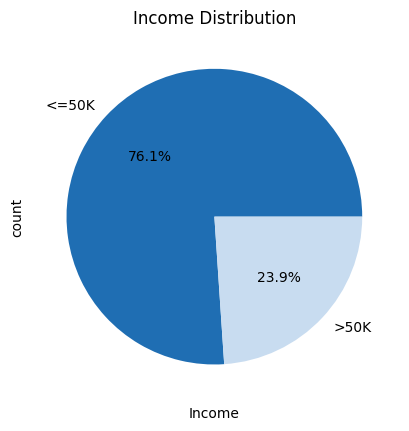

In [75]:
# Income - Pie Chart  --> 4 groups / we want to plop freqency of blues color(Monochrome)

income_count = df_processed['income'].value_counts()
cmap = plt.get_cmap('Blues')
portion_list = df_processed['income'].value_counts().values / df_processed['income'].value_counts().sum()
color = cmap(portion_list)
income_count.plot(
    kind='pie',
    colors=color,
    labels=df_processed['income'].unique(),
    autopct= '%1.1f%%',
                )

plt.title('Income Distribution')
plt.xlabel('Income')
#plt.ylabel('Frequency')  Pie charts typically don't have y-axis label
plt.show()


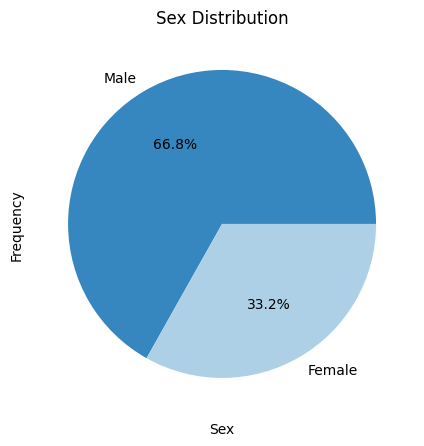

In [76]:
# Sex - Pie Chart  --> 2 groups +> Recommand! 
sex_count = df_processed['sex'].value_counts()
cmap = plt.get_cmap('Blues')
portion_list = df_processed['sex'].value_counts().values / df_processed['sex'].value_counts().sum()
color = cmap(portion_list)
sex_count.plot(
    kind='pie',
    figsize=(10, 5),
    grid=True,
    colors=color,
    labels=df['sex'].unique(),
    autopct= '%1.1f%%',
            )

plt.title('Sex Distribution')
plt.xlabel('Sex')
plt.ylabel('Frequency')
plt.show()


In [77]:
df_processed.race.unique()

['Black', 'White', 'Asian-Pac-Islander', 'Other', 'Amer-Indian-Eskimo']
Categories (5, object): ['Amer-Indian-Eskimo', 'Asian-Pac-Islander', 'Black', 'Other', 'White']

#### 5- Stack bar:

A stacked bar chart is a type of bar chart that portrays the compositions and comparisons of several variables through time

* Income by Education and Race:

Races found: ['Amer-Indian-Eskimo', 'Asian-Pac-Islander', 'Black', 'Other', 'White']

Pivot table shape: (16, 5)
Pivot table columns: ['Amer-Indian-Eskimo', 'Asian-Pac-Islander', 'Black', 'Other', 'White']


C:\Users\parsayan\AppData\Local\Temp\ipykernel_44932\3659025655.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_data = df_processed.groupby(['education', 'race'])['income_numeric'].mean().unstack()


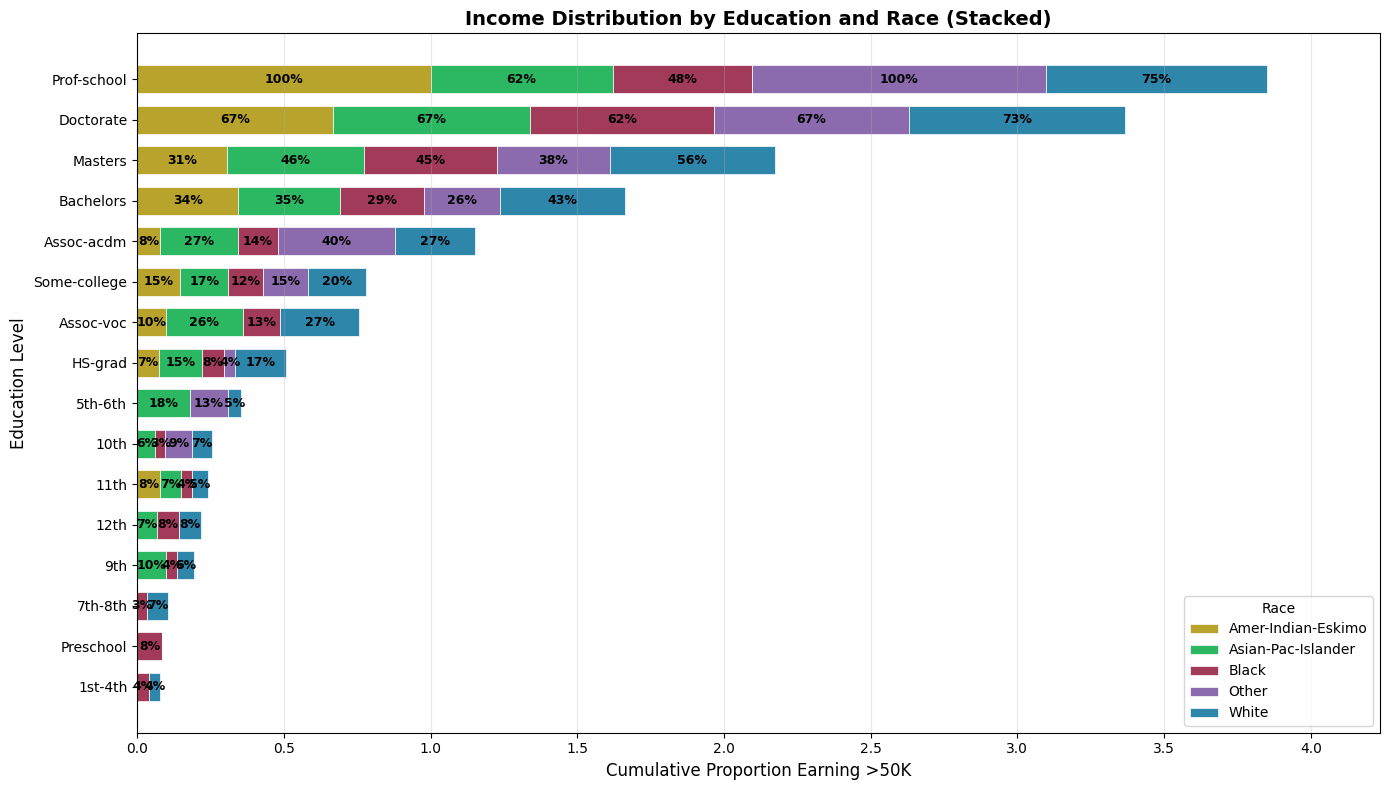


COMPREHENSIVE SUMMARY: INCOME BY EDUCATION AND RACE

1st-4th:
----------------------------------------
  Amer-Indian-Eskimo       : 0.0%
  Asian-Pac-Islander       : 0.0%
  Black                    : 4.2%
  Other                    : 0.0%
  White                    : 3.6%
  ───────────────────────────────────
  Highest: Black (4.2%)
  Lowest:  Amer-Indian-Eskimo (0.0%)
  Gap:     4.2%

Preschool:
----------------------------------------
  Amer-Indian-Eskimo       : 0.0%
  Asian-Pac-Islander       : 0.0%
  Black                    : 8.3%
  Other                    : 0.0%
  White                    : 0.0%
  ───────────────────────────────────
  Highest: Black (8.3%)
  Lowest:  Amer-Indian-Eskimo (0.0%)
  Gap:     8.3%

7th-8th:
----------------------------------------
  Amer-Indian-Eskimo       : 0.0%
  Asian-Pac-Islander       : 0.0%
  Black                    : 3.3%
  Other                    : 0.0%
  White                    : 7.2%
  ───────────────────────────────────
  Highest: Whi

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Calculate the data
df_processed['income_numeric'] = (df_processed['income'].astype(str).str.strip() == '>50K').astype(int)

# Get all races dynamically
races = df_processed['race'].unique()
races_sorted = sorted(races)
print(f"Races found: {races_sorted}")

# Create pivot table
pivot_data = df_processed.groupby(['education', 'race'])['income_numeric'].mean().unstack()

# Fill NaN values with 0
pivot_data = pivot_data.fillna(0)

# Sort by average across all races
pivot_data['avg'] = pivot_data.mean(axis=1)
pivot_data = pivot_data.sort_values('avg', ascending=True)  # Ascending for horizontal bars
pivot_data = pivot_data.drop('avg', axis=1)

print("\nPivot table shape:", pivot_data.shape)
print("Pivot table columns:", pivot_data.columns.tolist())

# Define colors for races
race_colors = {
    'White': '#2E86AB',
    'Black': '#A23B59',
    'Asian-Pac-Islander': '#2CB862',
    'Amer-Indian-Eskimo': '#B8A32C',
    'Other': '#8B6BAE'
}


# Stacked horizontal bars showing composition
fig, ax = plt.subplots(figsize=(14, 8))

# Calculate proportions for stacked bars
pivot_data_for_stack = pivot_data.copy()

# Create stacked horizontal bars
left = np.zeros(len(pivot_data_for_stack))
for race in pivot_data_for_stack.columns:
    bars = ax.barh(pivot_data_for_stack.index, pivot_data_for_stack[race], 
                   left=left, label=race, height=0.7,
                   color=race_colors.get(race, '#808080'),
                   edgecolor='white', linewidth=0.5)
    
    # Add percentage labels in the middle of each segment
    for bar, val in zip(bars, pivot_data_for_stack[race]):
        if val > 0.02:  # Only label if significant
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height()/2,
                   f'{val:.0%}', ha='center', va='center', fontsize=9, fontweight='bold')
    
    left += pivot_data_for_stack[race].values

ax.set_xlabel('Cumulative Proportion Earning >50K', fontsize=12)
ax.set_ylabel('Education Level', fontsize=12)
ax.set_title('Income Distribution by Education and Race (Stacked)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10, title='Race')
ax.set_xlim(0, left.max() * 1.1)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Print comprehensive summary
print("\n" + "="*80)
print("COMPREHENSIVE SUMMARY: INCOME BY EDUCATION AND RACE")
print("="*80)

for edu in pivot_data.index:
    print(f"\n{edu}:")
    print("-" * 40)
    for race in pivot_data.columns:
        val = pivot_data.loc[edu, race]
        print(f"  {race:<25}: {val:.1%}")
    
    # Find the race with highest proportion
    max_race = pivot_data.loc[edu].idxmax()
    min_race = pivot_data.loc[edu].idxmin()
    max_val = pivot_data.loc[edu, max_race]
    min_val = pivot_data.loc[edu, min_race]
    diff = max_val - min_val
    print(f"  {'─' * 35}")
    print(f"  Highest: {max_race} ({max_val:.1%})")
    print(f"  Lowest:  {min_race} ({min_val:.1%})")
    print(f"  Gap:     {diff:.1%}")

#### 6- Heatmap plot:

The heat map (also called a clustergram) is a graphic representation of the unsupervised hierarchical clustering of target (gene) expression
 
across all samples or biogroups in the study. In the plot, the targets and samples are arranged according to the similarity of their gene

expression. 


C:\Users\parsayan\AppData\Local\Temp\ipykernel_44932\673445029.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_data = pivot_data.applymap(lambda x: f'{x:.1%}' if x > 0 else '')


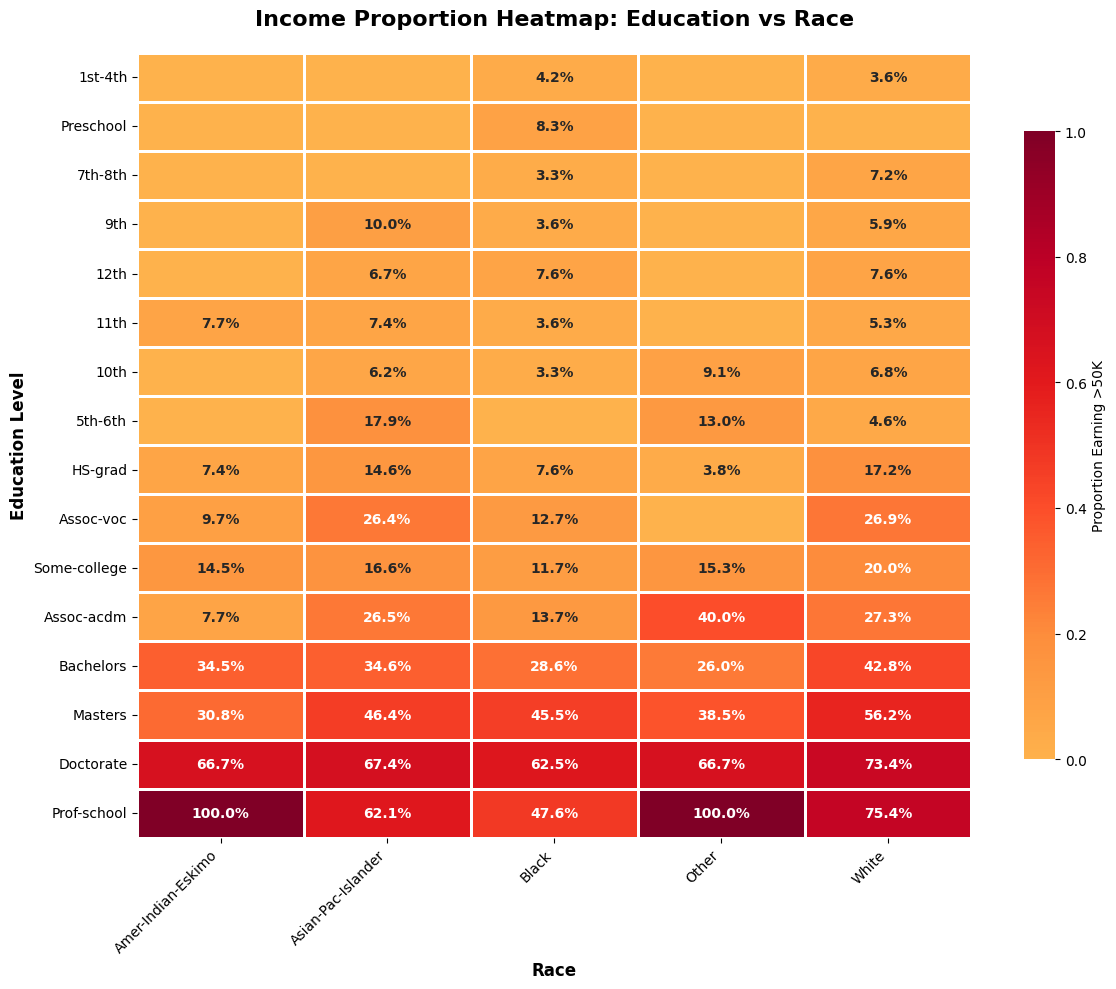

In [79]:
import seaborn as sns

# Create heatmap
fig, ax = plt.subplots(figsize=(12, 10))

# Create annotation text
annot_data = pivot_data.applymap(lambda x: f'{x:.1%}' if x > 0 else '')

sns.heatmap(pivot_data, 
            annot=annot_data, 
            fmt='', 
            cmap='YlOrRd',  # Yellow-Orange-Red colormap
            vmin=0, 
            vmax=pivot_data.max().max(),
            center=pivot_data.values.mean(),
            linewidths=1,
            linecolor='white',
            cbar_kws={'label': 'Proportion Earning >50K', 'shrink': 0.8},
            ax=ax,
            annot_kws={'fontsize': 10, 'fontweight': 'bold'})

ax.set_title('Income Proportion Heatmap: Education vs Race', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Race', fontsize=12, fontweight='bold')
ax.set_ylabel('Education Level', fontsize=12, fontweight='bold')

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

*** Function to compare all plots:

C:\Users\parsayan\AppData\Local\Temp\ipykernel_44932\8102226.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_data = df.groupby(['education', 'race'])['income_numeric'].mean().unstack().fillna(0)
C:\Users\parsayan\AppData\Local\Temp\ipykernel_44932\8102226.py:81: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  overall_race = df.groupby('race')['income_numeric'].mean().sort_values(ascending=True)


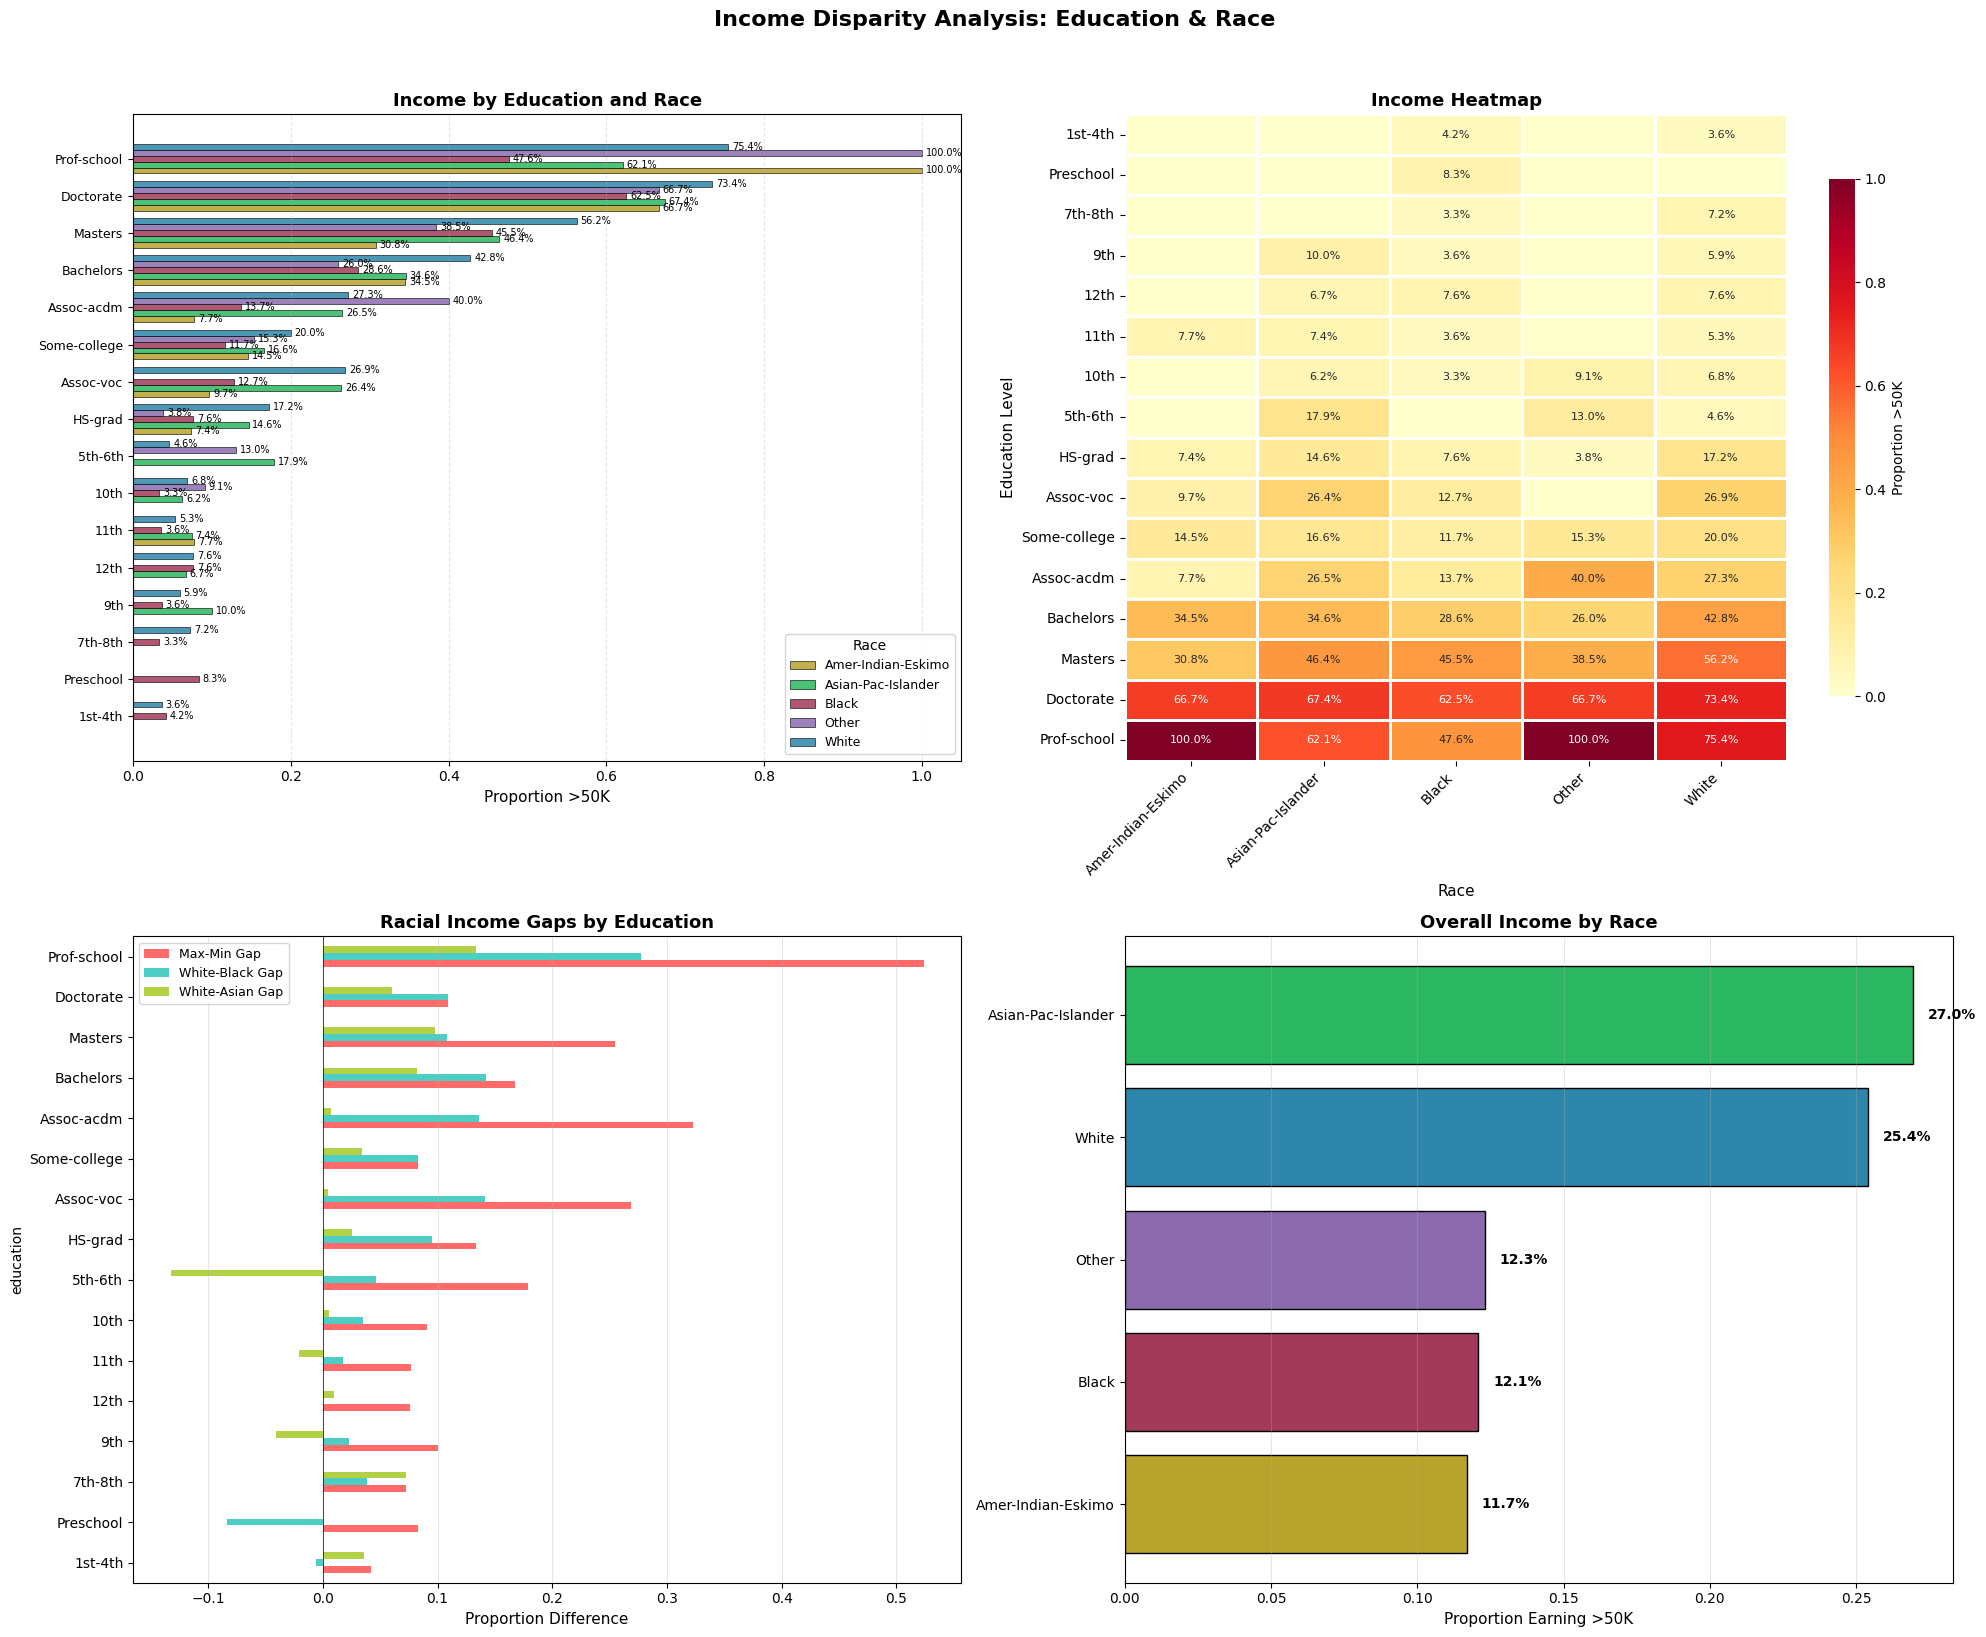


STATISTICAL SUMMARY

Overall income >50K rate: 23.9%

By Race:
  Amer-Indian-Eskimo       : 11.7%
  Black                    : 12.1%
  Other                    : 12.3%
  White                    : 25.4%
  Asian-Pac-Islander       : 27.0%

Largest gaps:

Top 10 largest gaps:
  Education             Race 1             Race 2      Gap
Prof-school              Black              Other 0.523810
Prof-school Amer-Indian-Eskimo              Black 0.523810
Prof-school Asian-Pac-Islander              Other 0.379310
Prof-school Amer-Indian-Eskimo Asian-Pac-Islander 0.379310
 Assoc-acdm Amer-Indian-Eskimo              Other 0.323077
Prof-school              Black              White 0.277820
  Assoc-voc              Other              White 0.268590
  Assoc-voc Asian-Pac-Islander              Other 0.264151
 Assoc-acdm              Black              Other 0.263354
    Masters Amer-Indian-Eskimo              White 0.254728


In [81]:
def plot_race_education_income_analysis(df):
    """
    Comprehensive dashboard showing income disparities by education and race
    """
    # Prepare data
    df['income_numeric'] = (df['income'].astype(str).str.strip() == '>50K').astype(int)
    pivot_data = df.groupby(['education', 'race'])['income_numeric'].mean().unstack().fillna(0)
    
    # Sort education by average income
    edu_order = pivot_data.mean(axis=1).sort_values(ascending=True).index
    pivot_data = pivot_data.loc[edu_order]
    
    races = pivot_data.columns.tolist()
    n_races = len(races)
    
    # Define colors
    race_colors = {
        'White': '#2E86AB',
        'Black': '#A23B59',
        'Asian-Pac-Islander': '#2CB862',
        'Amer-Indian-Eskimo': '#B8A32C',
        'Other': '#8B6BAE'
    }
    
    # Create dashboard
    fig = plt.figure(figsize=(20, 16))
    
    # 1. Main horizontal bar chart
    ax1 = plt.subplot(2, 2, 1)
    bar_height = 0.8 / n_races
    y_positions = np.arange(len(pivot_data.index))
    
    for i, race in enumerate(pivot_data.columns):
        offset = (i - (n_races - 1) / 2) * bar_height
        bars = ax1.barh(y_positions + offset, pivot_data[race], bar_height,
                        label=race, color=race_colors.get(race, '#808080'),
                        edgecolor='black', linewidth=0.5, alpha=0.85)
        
        for bar in bars:
            width = bar.get_width()
            if width > 0.03:
                ax1.text(width + 0.005, bar.get_y() + bar.get_height()/2,
                        f'{width:.1%}', ha='left', va='center', fontsize=7)
    
    ax1.set_yticks(y_positions)
    ax1.set_yticklabels(pivot_data.index, fontsize=9)
    ax1.set_xlabel('Proportion >50K', fontsize=11)
    ax1.set_title('Income by Education and Race', fontsize=13, fontweight='bold')
    ax1.legend(loc='lower right', fontsize=9, title='Race')
    ax1.grid(axis='x', alpha=0.3, linestyle='--')
    
    # 2. Heatmap
    ax2 = plt.subplot(2, 2, 2)
    annot_data = pivot_data.map(lambda x: f'{x:.1%}' if x > 0 else '')
    sns.heatmap(pivot_data, annot=annot_data, fmt='', cmap='YlOrRd',
                vmin=0, linewidths=1, linecolor='white',
                cbar_kws={'label': 'Proportion >50K', 'shrink': 0.8},
                ax=ax2, annot_kws={'fontsize': 8})
    ax2.set_title('Income Heatmap', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Race', fontsize=11)
    ax2.set_ylabel('Education Level', fontsize=11)
    plt.sca(ax2)
    plt.xticks(rotation=45, ha='right')
    
    # 3. Racial gap analysis
    ax3 = plt.subplot(2, 2, 3)
    race_gaps = pd.DataFrame({
        'Max-Min Gap': pivot_data.max(axis=1) - pivot_data.min(axis=1),
        'White-Black Gap': pivot_data.get('White', 0) - pivot_data.get('Black', 0),
        'White-Asian Gap': pivot_data.get('White', 0) - pivot_data.get('Asian-Pac-Islander', 0)
    })
    race_gaps.plot(kind='barh', ax=ax3, color=['#FF6B6B', '#4ECDC4', "#B3D145"])
    ax3.set_title('Racial Income Gaps by Education', fontsize=13, fontweight='bold')
    ax3.set_xlabel('Proportion Difference', fontsize=11)
    ax3.legend(fontsize=9)
    ax3.axvline(x=0, color='black', linewidth=0.5)
    ax3.grid(axis='x', alpha=0.3)
    
    # 4. Overall racial comparison
    ax4 = plt.subplot(2, 2, 4)
    overall_race = df.groupby('race')['income_numeric'].mean().sort_values(ascending=True)
    colors = [race_colors.get(race, '#808080') for race in overall_race.index]
    bars = ax4.barh(overall_race.index, overall_race.values, color=colors, edgecolor='black')
    
    for bar, val in zip(bars, overall_race.values):
        ax4.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.1%}', ha='left', va='center', fontsize=10, fontweight='bold')
    
    ax4.set_title('Overall Income by Race', fontsize=13, fontweight='bold')
    ax4.set_xlabel('Proportion Earning >50K', fontsize=11)
    ax4.grid(axis='x', alpha=0.3)
    
    plt.suptitle('Income Disparity Analysis: Education & Race', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Print statistical summary
    print("\n" + "="*80)
    print("STATISTICAL SUMMARY")
    print("="*80)
    print(f"\nOverall income >50K rate: {df['income_numeric'].mean():.1%}")
    print("\nBy Race:")
    for race in overall_race.index:
        print(f"  {race:<25}: {overall_race[race]:.1%}")
    
    print("\nLargest gaps:")
    gaps = []
    for edu in pivot_data.index:
        for i, r1 in enumerate(races):
            for r2 in races[i+1:]:
                gap = abs(pivot_data.loc[edu, r1] - pivot_data.loc[edu, r2])
                if gap > 0.05:  # Only show significant gaps
                    gaps.append({
                        'Education': edu,
                        'Race 1': r1,
                        'Race 2': r2,
                        'Gap': gap
                    })
    
    if gaps:
        gaps_df = pd.DataFrame(gaps).sort_values('Gap', ascending=False).head(10)
        print("\nTop 10 largest gaps:")
        print(gaps_df.to_string(index=False))

# Run the dashboard
plot_race_education_income_analysis(df_processed)

## Continue in Data Visualization-3D Plotting:

### Iris Dataset

In [82]:
from sklearn.datasets import load_iris

# Load the Iris Dataset
iris = load_iris()
df = pd.DataFrame(
    data=iris.data,
    columns=iris.feature_names,
    )

#### 1- Scatter plot:

A scatter plot, also called a scatterplot, scatter graph, scatter chart, scattergram, or scatter diagram, is a type of plot or mathematical 

diagram using Cartesian coordinates to display values for typically two variables for a set of data

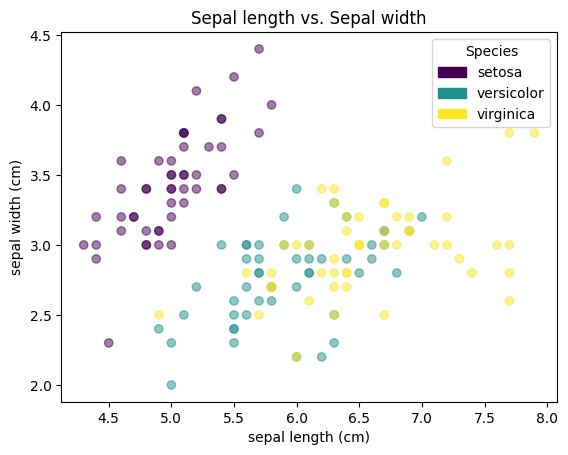

In [83]:
plt.scatter(
    df['sepal length (cm)'],
    df['sepal width (cm)'],
    c=iris.target,
    alpha=0.5,
    )
plt.title('Sepal length vs. Sepal width')
plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')

# Create custom legend (show cluster's name)
# import matplotlib.patches as mpatches
legend_labels = [mpatches.Patch(color=plt.cm.viridis(i / 2), label=name) for i, name in enumerate(iris.target_names)]
plt.legend(handles=legend_labels, title='Species')

plt.show()


- few plots besides each other --> Subplot

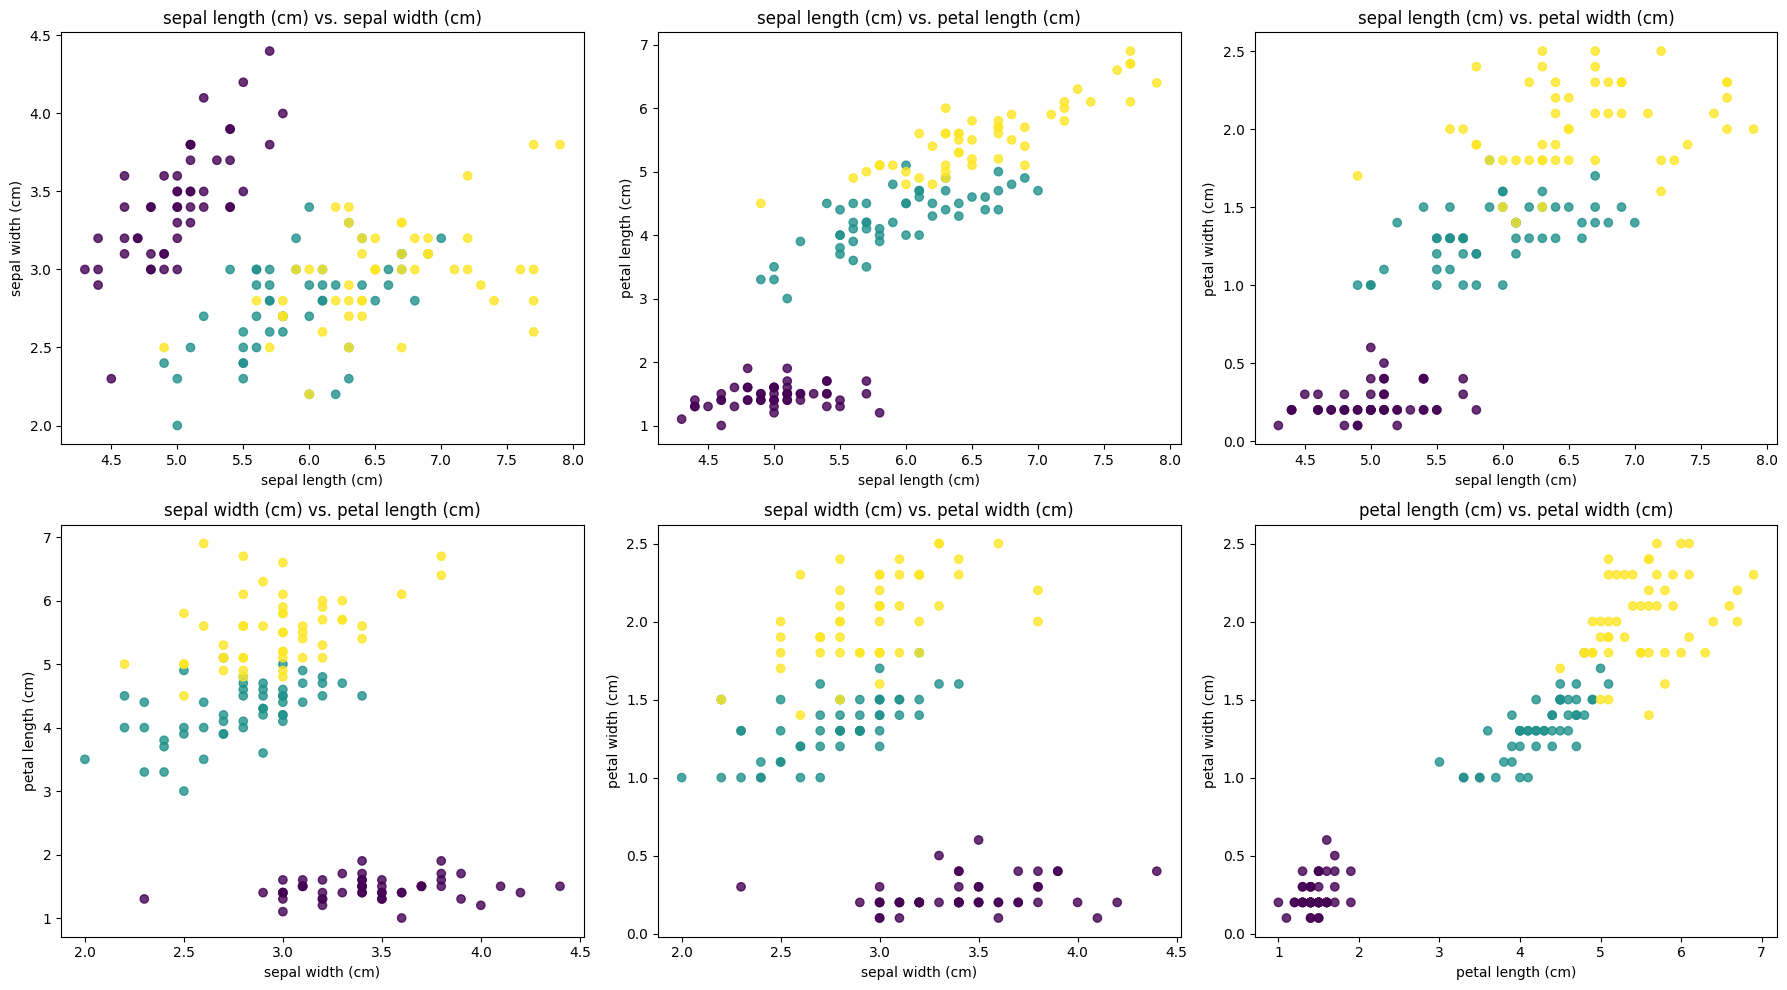

In [87]:

# Define the feature pairs for the scatter plots
feature_pairs = [
        ('sepal length (cm)', 'sepal width (cm)'),
        ('sepal length (cm)', 'petal length (cm)'),
        ('sepal length (cm)', 'petal width (cm)'),
        ('sepal width (cm)', 'petal length (cm)'),
        ('sepal width (cm)', 'petal width (cm)'),
        ('petal length (cm)', 'petal width (cm)'),
    ]
# Create a figure with 6 subplots (2 rows by 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Flatten the axes array for easy itteration
axes = axes.flatten()

# Loop through the feature pairs and corresponding axes
for i, (x_feature, y_feature) in enumerate(feature_pairs):
    scatter = axes[i].scatter(
        df[x_feature],
        df[y_feature],
        c=iris.target,
        alpha=0.8,
        cmap='viridis',
        )
    axes[i].set_title(f'{x_feature} vs. {y_feature}')
    axes[i].set_xlabel(x_feature)
    axes[i].set_ylabel(y_feature)

# Adjust the layout to prevent overlapping title/label
plt.tight_layout()
plt.show()

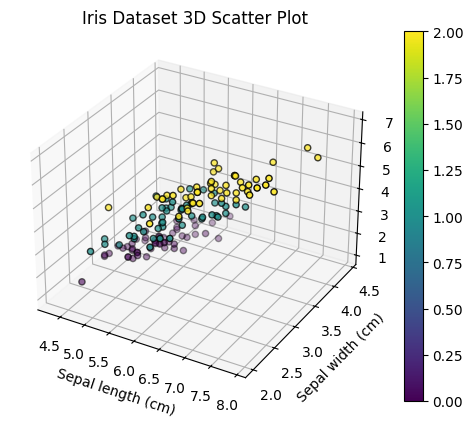

In [88]:
# 3D Plotting

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d') # 111 --> 1:row, 1:column, 1:plot

# Scatter plot for sepal length, sepal width and petal length
sc = ax.scatter(
    df['sepal length (cm)'],
    df['sepal width (cm)'],
    df['petal length (cm)'],
    c=iris.target,
    cmap='viridis',
    edgecolor='k',
    )
# labels and titles
ax.set_xlabel('Sepal length (cm)')
ax.set_ylabel('Sepal width (cm)')
ax.set_zlabel('Petal length (cm)')
plt.title('Iris Dataset 3D Scatter Plot')
plt.colorbar(sc)
plt.show()


#### 3D Plot with plotly.express --> px

In [91]:
from sklearn.datasets import load_iris
import pandas as pd
import plotly.express as px

# Load the iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add species names instead of numbers
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Verify columns
print("Columns:", df.columns.tolist())
print("\nFirst 3 rows:")
print(df.head(3))

# Plotly Express interactive 3D scatter plot
fig = px.scatter_3d(
    df,
    x='sepal length (cm)',      # Correct spelling
    y='sepal width (cm)',       # Correct spelling
    z='petal length (cm)',      # Correct spelling
    color='species',
    title='Interactive 3D Scatter Plot of Iris Dataset',
    labels={'species': 'Species'},
    color_discrete_map={
        'setosa': '#FF6B6B',
        'versicolor': '#4ECDC4',
        'virginica': "#A0CE23"
    },
    symbol='species',  # Different symbols for each species
    size_max=10,
    opacity=0.8
)

fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=30),
    scene=dict(
        xaxis_title='Sepal Length (cm)',
        yaxis_title='Sepal Width (cm)',
        zaxis_title='Petal Length (cm)'
    )
)

fig.show()

Columns: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species']

First 3 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  


#### Treemap:

In information visualization and computing, treemapping is a method for displaying hierarchical data using nested figures, usually rectangles.

In [95]:
import plotly.express as px
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Create a long format dataframe manually
treemap_data = []

for species in df['species'].unique():
    species_data = df[df['species'] == species]
    for feature in iris.feature_names:
        treemap_data.append({
            'species': species,
            'feature': feature,
            'mean_value': species_data[feature].mean()
        })

df_treemap = pd.DataFrame(treemap_data)

print("Treemap data:")
print(df_treemap)

# Create treemap
fig = px.treemap(
    df_treemap,
    path=['species', 'feature'],
    values='mean_value',
    title='Iris Dataset: Mean Feature Values by Species',
    color='species',
    color_discrete_map={
        'setosa': '#FF6B6B',
        'versicolor': '#4ECDC4',
        'virginica': "#A7D145"
    }
)

fig.update_traces(
    textinfo='label+value',
    texttemplate='%{label}<br>%{value:.2f} cm',
    hovertemplate='<b>%{label}</b><br>Mean: %{value:.2f} cm<extra></extra>'
)

fig.show()

Treemap data:
       species            feature  mean_value
0       setosa  sepal length (cm)       5.006
1       setosa   sepal width (cm)       3.428
2       setosa  petal length (cm)       1.462
3       setosa   petal width (cm)       0.246
4   versicolor  sepal length (cm)       5.936
5   versicolor   sepal width (cm)       2.770
6   versicolor  petal length (cm)       4.260
7   versicolor   petal width (cm)       1.326
8    virginica  sepal length (cm)       6.588
9    virginica   sepal width (cm)       2.974
10   virginica  petal length (cm)       5.552
11   virginica   petal width (cm)       2.026


#### Sunburst chart: 

Sunburst plots visualize hierarchical data spanning outwards radially from root to leaves.

In [98]:
import plotly.express as px
import pandas as pd
from sklearn.datasets import load_iris

# Load iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Convert species to regular strings (NOT categorical)
df['species'] = [iris.target_names[i] for i in iris.target]

# Calculate mean feature values per species
mean_features = df.groupby('species').mean().reset_index()

# Melt the data
df_melted = mean_features.melt(
    id_vars=['species'], 
    var_name='feature', 
    value_name='mean_value'
)

# Convert to regular Python strings (not categorical)
df_melted['species'] = df_melted['species'].astype(str)
df_melted['feature'] = df_melted['feature'].astype(str)

# Verify data types
print("Data types:")
print(df_melted.dtypes)

# Sunburst chart - should work now!
fig = px.sunburst(
    df_melted,
    path=['species', 'feature'],
    values='mean_value',
    title='Iris Dataset: Mean Feature Values by Species (Sunburst)',
    color='species',
    color_discrete_map={
        'setosa': '#FF6B6B',
        'versicolor': '#4ECDC4',
        'virginica': "#89D145"
    }
)

fig.update_traces(
    textinfo='label+percent parent',
    insidetextorientation='radial'
)

fig.update_layout(
    width=800,
    height=800
)

fig.show()

Data types:
species        object
feature        object
mean_value    float64
dtype: object


#### Alternative Sunburst Using Graph Objects (More Control):

In [99]:
import plotly.graph_objects as go
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = [iris.target_names[i] for i in iris.target]

# Prepare hierarchy data
mean_features = df.groupby('species').mean()

# Build sunburst data manually
labels = ["Iris"]  # Root
parents = [""]
values = [mean_features.sum().sum()]

# Species colors
species_colors = {
    'setosa': '#FF6B6B',
    'versicolor': '#4ECDC4',
    'virginica': '#45B7D1'
}

# Add species and features
for species in iris.target_names:
    species_total = mean_features.loc[species].sum()
    labels.append(species)
    parents.append("Iris")
    values.append(species_total)
    
    for feature in iris.feature_names:
        labels.append(f"{feature}")
        parents.append(species)
        values.append(mean_features.loc[species, feature])

# Create sunburst
fig = go.Figure(go.Sunburst(
    labels=labels,
    parents=parents,
    values=values,
    branchvalues="total",
    marker=dict(
        colors=[
            'lightgray',  # Root
            species_colors['setosa'], 
            '#FFB3B3', '#FFB3B3', '#FFB3B3', '#FFB3B3',  # Setosa features
            species_colors['versicolor'], 
            '#B3E8E0', '#B3E8E0', '#B3E8E0', '#B3E8E0',  # Versicolor features
            species_colors['virginica'], 
            '#B3D8FF', '#B3D8FF', '#B3D8FF', '#B3D8FF',  # Virginica features
        ]
    ),
    textinfo='label+value',
    texttemplate='%{label}<br>%{value:.1f} cm',
))

fig.update_layout(
    title='Iris Dataset: Mean Feature Values by Species',
    width=800,
    height=800
)

fig.show()

#### Scatter Matrix:

A Scatter Matrix (also called a pairplot or scatterplot matrix) is a grid of scatter plots that shows the relationships between every pair of features in your dataset all at once.

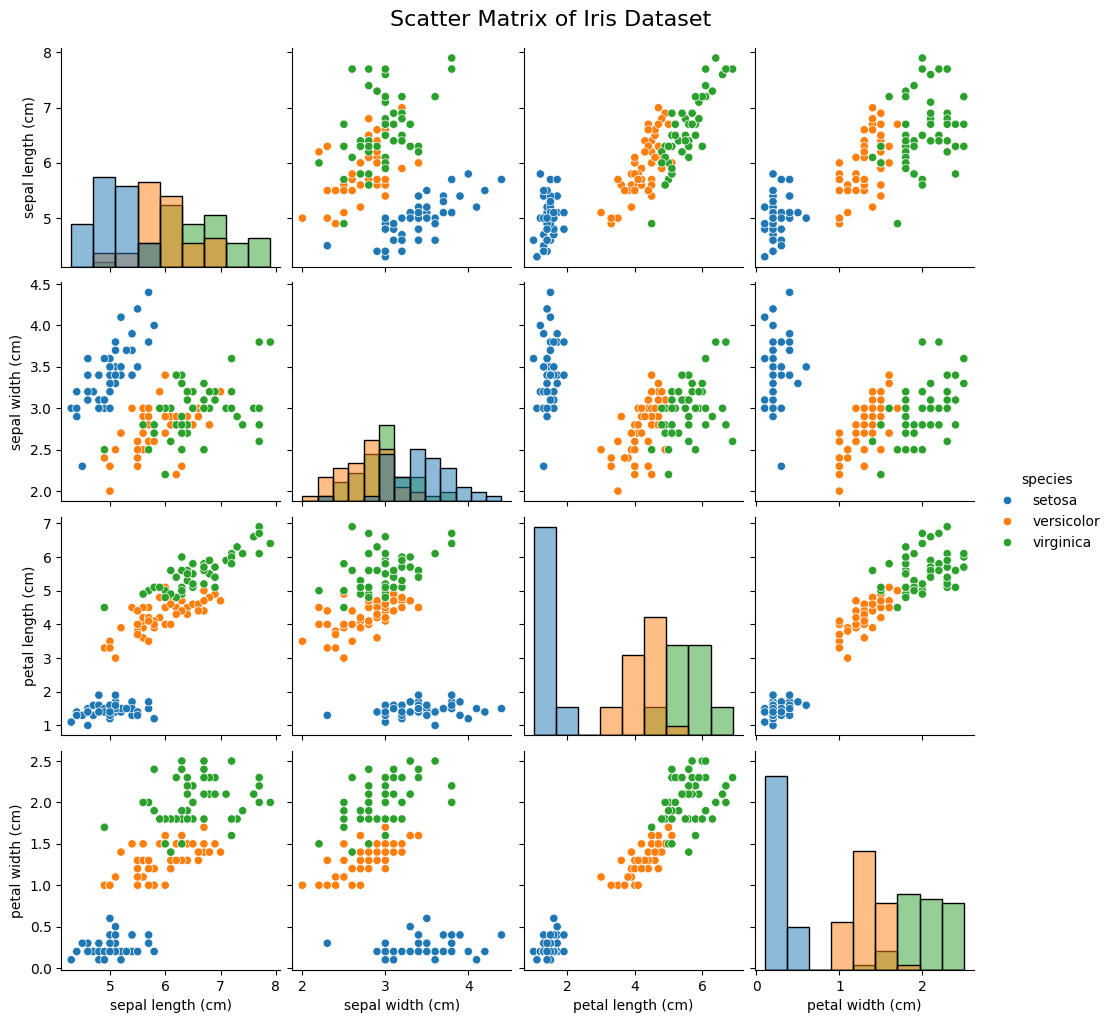

In [100]:
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = [iris.target_names[i] for i in iris.target]

# This one line creates all pairwise plots automatically!
sns.pairplot(df, hue='species', diag_kind='hist', height=2.5)
plt.suptitle('Scatter Matrix of Iris Dataset', y=1.02, fontsize=16)
plt.show()

* Why Use a Scatter Matrix?

    Quick overview: See all relationships at once

    Pattern detection: Spot correlations, clusters, outliers

    Feature selection: Identify which features best separate your classes

    Data quality: Spot unusual data points or errors

## The End